**Proyecto: Diagnosico fitosanitario para cultivos de tomate**

# Pre-Procesamiento de datos

## Instalaciones

In [ ]:
!pip install kagglehub scikit-image --quiet

## Importaciones

In [ ]:

import os
import random
import warnings
import numpy as np
import pandas as pd
import cv2
from scipy.stats import skew
from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split
import kagglehub

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

## DESCARGA DEL DATASET

In [ ]:
ruta_dataset = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
print("Path to dataset files:", ruta_dataset)

ruta_segmentadas = os.path.join(ruta_dataset, "plantvillage dataset", "segmented")
print("Ruta de imagenes segmentadas:", ruta_segmentadas)


100%|██████████| 2.04G/2.04G [00:38<00:00, 57.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/versions/3
Ruta de imagenes segmentadas: /root/.cache/kagglehub/datasets/abdallahalidev/plantvillage-dataset/versions/3/plantvillage dataset/segmented


## DEFINICIÓN DE CLASES (subconjunto de 4)

In [ ]:
CLASES_OBJETIVO = [
    "Tomato___Early_blight",
    "Tomato___Bacterial_spot",
    "Tomato___healthy",
    "Tomato___Tomato_Yellow_Leaf_Curl_Virus",
]

# Verificación rápida de disponibilidad y conteo por clase
print("\nConteo original por clase:")
conteo_por_clase = {}
for clase in CLASES_OBJETIVO:
    ruta_clase = os.path.join(ruta_segmentadas, clase)
    imagenes   = [f for f in os.listdir(ruta_clase)
                  if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    conteo_por_clase[clase] = imagenes
    print(f"  {clase:<55} {len(imagenes):>5} imágenes")




Conteo original por clase:
  Tomato___Early_blight                                    1000 imágenes
  Tomato___Bacterial_spot                                  2127 imágenes
  Tomato___healthy                                         1591 imágenes
  Tomato___Tomato_Yellow_Leaf_Curl_Virus                   5357 imágenes


# Procesamiento de datos

 ## EXTRACCIÓN DE CARACTERÍSTICAS

In [ ]:
DISTANCIAS_GLCM = [1]
ANGULOS_GLCM    = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]

def crear_mascara(img_bgr: np.ndarray) -> np.ndarray:
    """
    Devuelve una máscara booleana que excluye el fondo negro de las
    imágenes segmentadas de PlantVillage.
    Un píxel es fondo si todos sus canales BGR son ≤ 15.
    """
    return ~(
        (img_bgr[:, :, 0] <= 15) &
        (img_bgr[:, :, 1] <= 15) &
        (img_bgr[:, :, 2] <= 15)
    )

def extraer_caracteristicas(ruta_imagen: str) -> dict | None:
    """
    Calcula el vector de características completo para una imagen.
    Retorna None si la imagen no puede leerse o si la máscara está vacía.
    """
    img_bgr = cv2.imread(ruta_imagen)
    if img_bgr is None:
        return None

    mascara = crear_mascara(img_bgr)
    if mascara.sum() == 0:
        return None

    feats = {}

    # ── 5.1 Características RGB ───────────────────────────────────────────────
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    nombres_rgb = ["R", "G", "B"]
    for idx, canal in enumerate(nombres_rgb):
        valores = img_rgb[:, :, idx][mascara].astype(np.float32)
        feats[f"mean_{canal}"] = float(np.mean(valores))
        feats[f"std_{canal}"]  = float(np.std(valores))
        feats[f"var_{canal}"]  = float(np.var(valores))
        feats[f"skew_{canal}"] = float(skew(valores))

    # ── 5.2 Características HSV ───────────────────────────────────────────────
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    nombres_hsv = ["H", "S", "V"]
    for idx, canal in enumerate(nombres_hsv):
        valores = img_hsv[:, :, idx][mascara].astype(np.float32)
        feats[f"mean_{canal}"] = float(np.mean(valores))
        feats[f"std_{canal}"]  = float(np.std(valores))

    # ── 5.3 Características LAB (CIELAB) ─────────────────────────────────────
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    nombres_lab = ["L", "A", "B_lab"]   # B_lab para no colisionar con B de RGB
    canales_lab = ["L", "A", "B"]
    for idx, (nombre, canal) in enumerate(zip(nombres_lab, canales_lab)):
        valores = img_lab[:, :, idx][mascara].astype(np.float32)
        feats[f"mean_{nombre}"] = float(np.mean(valores))
        feats[f"std_{nombre}"]  = float(np.std(valores))

    # ── 5.4 Textura GLCM ─────────────────────────────────────────────────────
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    # Aplicar máscara: rellenar fondo con 0 para que no aporte a la GLCM
    img_gray_masked = img_gray.copy()
    img_gray_masked[~mascara] = 0

    glcm = graycomatrix(
        img_gray_masked,
        distances=DISTANCIAS_GLCM,
        angles=ANGULOS_GLCM,
        levels=256,
        symmetric=True,
        normed=True,
    )
    # Promedio sobre distancias y ángulos para obtener un escalar por propiedad
    feats["contrast"]     = float(graycoprops(glcm, "contrast").mean())
    feats["homogeneity"]  = float(graycoprops(glcm, "homogeneity").mean())
    feats["energy"]       = float(graycoprops(glcm, "energy").mean())
    feats["correlation"]  = float(graycoprops(glcm, "correlation").mean())

    # ── 5.5 Índice ExG (Excess Green) ────────────────────────────────────────
    # ExG = 2·g_norm − r_norm − b_norm  (canales normalizados 0-1)
    r = img_rgb[:, :, 0][mascara].astype(np.float32) / 255.0
    g = img_rgb[:, :, 1][mascara].astype(np.float32) / 255.0
    b = img_rgb[:, :, 2][mascara].astype(np.float32) / 255.0
    exg_valores = 2.0 * g - r - b
    feats["ExG"] = float(np.mean(exg_valores))

    return feats


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## ITERACIÓN Y CONSTRUCCIÓN DEL DATAFRAME

In [ ]:
import os
import pandas as pd

ruta_features = '/content/drive/MyDrive/features.parquet'

if os.path.exists(ruta_features):
    print("Cargando features desde Drive...")
    df_features = pd.read_parquet(ruta_features)

else:
    print("Extrayendo caracteristicas...")

    registros = []
    errores = 0

    for clase, filenames in conteo_por_clase.items():
        for i, filename in enumerate(filenames):
            ruta = os.path.join(ruta_segmentadas, clase, filename)
            feats = extraer_caracteristicas(ruta)

            if feats is None:
                errores += 1
                continue

            feats["label"] = clase
            registros.append(feats)

        print(f"  OK {clase:<55} ({len(filenames)} imagenes procesadas)")

    df_features = pd.DataFrame(registros)

    print(f"\nGuardando en Drive...")
    df_features.to_parquet(ruta_features)

    print(f"Guardado en: {ruta_features}")
    print(f"Imagenes descartadas: {errores}")

print(f"\nDataFrame final: {df_features.shape[0]} filas x {df_features.shape[1]} columnas")
print(f"\nDistribucion de etiquetas:\n{df_features['label'].value_counts()}\n")
print(f"Columnas de caracteristicas:\n{[c for c in df_features.columns if c != 'label']}\n")


Cargando features desde Drive...

DataFrame final: 10075 filas x 30 columnas

Distribucion de etiquetas:
label
Tomato___Tomato_Yellow_Leaf_Curl_Virus    5357
Tomato___Bacterial_spot                   2127
Tomato___healthy                          1591
Tomato___Early_blight                     1000
Name: count, dtype: int64

Columnas de caracteristicas:
['mean_R', 'std_R', 'var_R', 'skew_R', 'mean_G', 'std_G', 'var_G', 'skew_G', 'mean_B', 'std_B', 'var_B', 'skew_B', 'mean_H', 'std_H', 'mean_S', 'std_S', 'mean_V', 'std_V', 'mean_L', 'std_L', 'mean_A', 'std_A', 'mean_B_lab', 'std_B_lab', 'contrast', 'homogeneity', 'energy', 'correlation', 'ExG']



## SEPARACIÓN DE CARACTERÍSTICAS Y ETIQUETAS

In [ ]:
X = df_features.drop(columns=["label"])
y = df_features["label"]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10075 entries, 0 to 10074
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   mean_R       10075 non-null  float64
 1   std_R        10075 non-null  float64
 2   var_R        10075 non-null  float64
 3   skew_R       10075 non-null  float64
 4   mean_G       10075 non-null  float64
 5   std_G        10075 non-null  float64
 6   var_G        10075 non-null  float64
 7   skew_G       10075 non-null  float64
 8   mean_B       10075 non-null  float64
 9   std_B        10075 non-null  float64
 10  var_B        10075 non-null  float64
 11  skew_B       10075 non-null  float64
 12  mean_H       10075 non-null  float64
 13  std_H        10075 non-null  float64
 14  mean_S       10075 non-null  float64
 15  std_S        10075 non-null  float64
 16  mean_V       10075 non-null  float64
 17  std_V        10075 non-null  float64
 18  mean_L       10075 non-null  float64
 19  std_

## TRAIN / TEST SPLIT (80 / 20, estratificado)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("─" * 55)
print("DIMENSIONES FINALES PARA LOS MODELOS")
print("─" * 55)
print(f"  X_train : {X_train.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  y_train : {y_train.shape}  — clases: {y_train.nunique()}")
print(f"  y_test  : {y_test.shape}   — clases: {y_test.nunique()}")
print("─" * 55)
print(f"\nDistribución en entrenamiento:\n{y_train.value_counts()}")
print(f"\nDistribución en prueba:\n{y_test.value_counts()}")


───────────────────────────────────────────────────────
DIMENSIONES FINALES PARA LOS MODELOS
───────────────────────────────────────────────────────
  X_train : (8060, 29)
  X_test  : (2015, 29)
  y_train : (8060,)  — clases: 4
  y_test  : (2015,)   — clases: 4
───────────────────────────────────────────────────────

Distribución en entrenamiento:
label
Tomato___Tomato_Yellow_Leaf_Curl_Virus    4285
Tomato___Bacterial_spot                   1702
Tomato___healthy                          1273
Tomato___Early_blight                      800
Name: count, dtype: int64

Distribución en prueba:
label
Tomato___Tomato_Yellow_Leaf_Curl_Virus    1072
Tomato___Bacterial_spot                    425
Tomato___healthy                           318
Tomato___Early_blight                      200
Name: count, dtype: int64


In [ ]:
df_features.head()

,mean_R,std_R,var_R,skew_R,mean_G,std_G,var_G,skew_G,mean_B,std_B,...,mean_A,std_A,mean_B_lab,std_B_lab,contrast,homogeneity,energy,correlation,ExG,label
0,88.777069,39.931263,1594.505615,-0.064012,92.985970,36.591660,1338.949585,0.090463,89.661964,44.076035,...,125.725212,5.529332,129.675018,7.701157,193.713532,0.154479,0.017033,0.933526,0.029541,Tomato___Early_blight
1,102.194374,46.874908,2197.257080,0.398939,104.452583,44.674175,1995.781860,0.113369,100.781410,47.229649,...,126.645561,6.318328,129.880112,8.872802,95.838100,0.221105,0.018700,0.977074,0.023253,Tomato___Early_blight
2,90.871773,51.729076,2675.897217,0.564673,95.706238,48.323147,2335.126465,0.252689,81.374634,54.127026,...,123.335182,7.918197,135.764877,8.922518,442.107613,0.134748,0.023345,0.915566,0.075161,Tomato___Early_blight
3,110.263412,35.154663,1235.850464,-0.426788,109.060417,33.851467,1145.921875,-0.600158,83.542816,46.009834,...,124.530983,7.569840,142.460648,14.815771,147.165851,0.177993,0.019002,0.940326,0.095351,Tomato___Early_blight
4,100.672028,41.607094,1731.150146,-0.114507,104.556946,29.426361,865.910767,-0.358095,98.074478,36.228188,...,125.003418,9.248676,131.557541,4.453473,257.412647,0.097401,0.014045,0.883085,0.040656,Tomato___Early_blight


# CLASIFICADORES

## Función Evaludaroa

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize

# --- CONFIGURACIÓN ESTÉTICA ---
NOMBRES_CORTOS = {
    'Tomato___Bacterial_spot':                'Bacterial Spot',
    'Tomato___Early_blight':                  'Early Blight',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 'Yellow Leaf Curl',
    'Tomato___healthy':                       'Healthy',
}
PALETTE = ['#3498db', '#e74c3c', '#2ecc71', '#f1c40f']
BG_COLOR = "#F8F9FA"

def evaluar_modelo_completo(modelo, X_train, X_test, y_train, y_test, nombre_modelo="Reporte"):
    # 1. Entrenar el modelo (Importante añadir esto si lo pasas en los argumentos)
    modelo.fit(X_train, y_train)

    # 2. Predicciones
    y_pred = modelo.predict(X_test)
    y_pred_proba = modelo.predict_proba(X_test)
    clases = modelo.classes_
    etiquetas_cortas = [NOMBRES_CORTOS.get(c, c) for c in clases]

    # 2. Métricas Globales
    acc = accuracy_score(y_test, y_pred)
    f1_m = f1_score(y_test, y_pred, average='macro')
    prec_m = precision_score(y_test, y_pred, average='macro')
    rec_m = recall_score(y_test, y_pred, average='macro')

    # 3. Preparar Reporte por Clase (DataFrame)
    report_dict = classification_report(y_test, y_pred, target_names=clases, output_dict=True)
    df_report = pd.DataFrame(report_dict).iloc[:-1, :len(clases)].T # Solo clases, sin promedios
    df_report.index = [NOMBRES_CORTOS.get(i, i) for i in df_report.index]

    # --- INICIO DE FIGURA ---
    fig = plt.figure(figsize=(16, 10), facecolor=BG_COLOR)
    gs = gridspec.GridSpec(3, 2, height_ratios=[0.15, 0.42, 0.42], hspace=0.35, wspace=0.25)

    fig.suptitle(f'ANÁLISIS DE RENDIMIENTO: {nombre_modelo}', fontsize=18, fontweight='bold', y=0.97)

    # A. TARJETAS DE MÉTRICAS (Fila Superior)
    ax_metrics = fig.add_subplot(gs[0, :])
    ax_metrics.axis('off')
    metricas_cards = [("Accuracy", acc), ("F1-Score", f1_m), ("Precision", prec_m), ("Recall", rec_m)]

    for i, (titulo, valor) in enumerate(metricas_cards):
        x_pos = 0.05 + (i * 0.24)
        ax_metrics.add_patch(mpatches.FancyBboxPatch((x_pos, 0.1), 0.18, 0.8, boxstyle="round,pad=0.02",
                                                    facecolor="white", edgecolor="#DCDDE1", transform=ax_metrics.transAxes))
        ax_metrics.text(x_pos + 0.09, 0.6, titulo, ha='center', fontsize=11, color="#7F8C8D", transform=ax_metrics.transAxes)
        ax_metrics.text(x_pos + 0.09, 0.25, f"{valor:.2%}", ha='center', fontsize=16, fontweight='bold', color="#2C3E50", transform=ax_metrics.transAxes)

    # B. REPORTE DETALLADO (Heatmap de métricas)
    ax_table = fig.add_subplot(gs[1, 0])
    sns.heatmap(df_report[['precision', 'recall', 'f1-score']], annot=True, fmt=".3f", cmap="YlGnBu",
                cbar=False, ax=ax_table, annot_kws={"size": 11})
    ax_table.set_title("Métricas por Categoría", fontsize=12, fontweight='bold', pad=15)
    ax_table.tick_params(axis='both', which='major', labelsize=10)

    # C. F1-SCORE POR CLASE (Gráfico de Barras)
    ax_bar = fig.add_subplot(gs[1, 1])
    colores_barras = PALETTE[:len(df_report)]
    sns.barplot(x=df_report['f1-score'], y=df_report.index, hue=df_report.index, palette=colores_barras, ax=ax_bar, legend=False)
    ax_bar.set_title("Comparativa F1-Score", fontsize=12, fontweight='bold', pad=15)
    ax_bar.set_xlim(0, 1.1)
    ax_bar.grid(axis='x', linestyle='--', alpha=0.6)

    # D. MATRIZ DE CONFUSIÓN (Normalizada para ver mejor los errores)
    ax_cm = fig.add_subplot(gs[2, 0])
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", ax=ax_cm,
                xticklabels=etiquetas_cortas, yticklabels=etiquetas_cortas, cbar=False)
    ax_cm.set_title("Matriz de Confusión (Frecuencias)", fontsize=12, fontweight='bold', pad=15)
    ax_cm.set_xlabel("Predicción")
    ax_cm.set_ylabel("Real")

    # E. CURVAS PRECISION-RECALL
    ax_pr = fig.add_subplot(gs[2, 1])
    y_test_bin = label_binarize(y_test, classes=clases)
    if len(clases) == 2: y_test_bin = np.hstack((1 - y_test_bin, y_test_bin)) # Caso binario

    for i in range(len(clases)):
        precision, recall, _ = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])
        ap = average_precision_score(y_test_bin[:, i], y_pred_proba[:, i])
        ax_pr.plot(recall, precision, label=f'{etiquetas_cortas[i]} (AP: {ap:.2f})', color=PALETTE[i % len(PALETTE)], lw=2)

    ax_pr.set_title("Curvas Precision-Recall", fontsize=12, fontweight='bold', pad=15)
    ax_pr.set_xlabel("Recall")
    ax_pr.set_ylabel("Precision")
    ax_pr.legend(fontsize=8, loc='lower left')
    ax_pr.grid(alpha=0.3)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

    return df_report

In [ ]:
from sklearn.model_selection import learning_curve
from sklearn.base import clone

def plot_learning_curve(estimator, title, X, y, axes=None, ylim=None,
                        cv=5, n_jobs=-1,
                        train_sizes=np.linspace(0.1, 1.0, 5),
                        scoring="f1_macro"):
    """Curva de aprendizaje: train (CV) vs validation (CV) sobre X,y.
    NO muta el estimator (usa clone). El eje X muestra muestras absolutas
    realmente usadas para entrenar en cada fold (siempre <= |X|*(cv-1)/cv).
    """
    if axes is None:
        _, axes = plt.subplots(1, 1, figsize=(10, 5))
    else:
        axes = axes[0]

    axes.set_title(title)
    if ylim is not None:
        axes.set_ylim(*ylim)
    axes.set_xlabel(f"Muestras de entrenamiento por fold (max teorico = {int(len(X)*(cv-1)/cv)} de {len(X)})")
    axes.set_ylabel(f"Score ({scoring})")

    train_sizes_abs, train_scores, cv_scores = learning_curve(
        clone(estimator), X, y,
        cv=cv, n_jobs=n_jobs,
        train_sizes=train_sizes,
        scoring=scoring,
        shuffle=True, random_state=42,
    )

    train_mean = train_scores.mean(axis=1); train_std = train_scores.std(axis=1)
    cv_mean    = cv_scores.mean(axis=1);    cv_std    = cv_scores.std(axis=1)

    axes.grid(alpha=0.3)
    axes.fill_between(train_sizes_abs, train_mean-train_std, train_mean+train_std,
                      alpha=0.1, color="r")
    axes.plot(train_sizes_abs, train_mean, "o-", color="r", label="Train (CV)")
    axes.fill_between(train_sizes_abs, cv_mean-cv_std, cv_mean+cv_std,
                      alpha=0.1, color="g")
    axes.plot(train_sizes_abs, cv_mean, "o-", color="g", label="Validacion (CV)")
    axes.legend(loc="best")
    return plt


## GNB

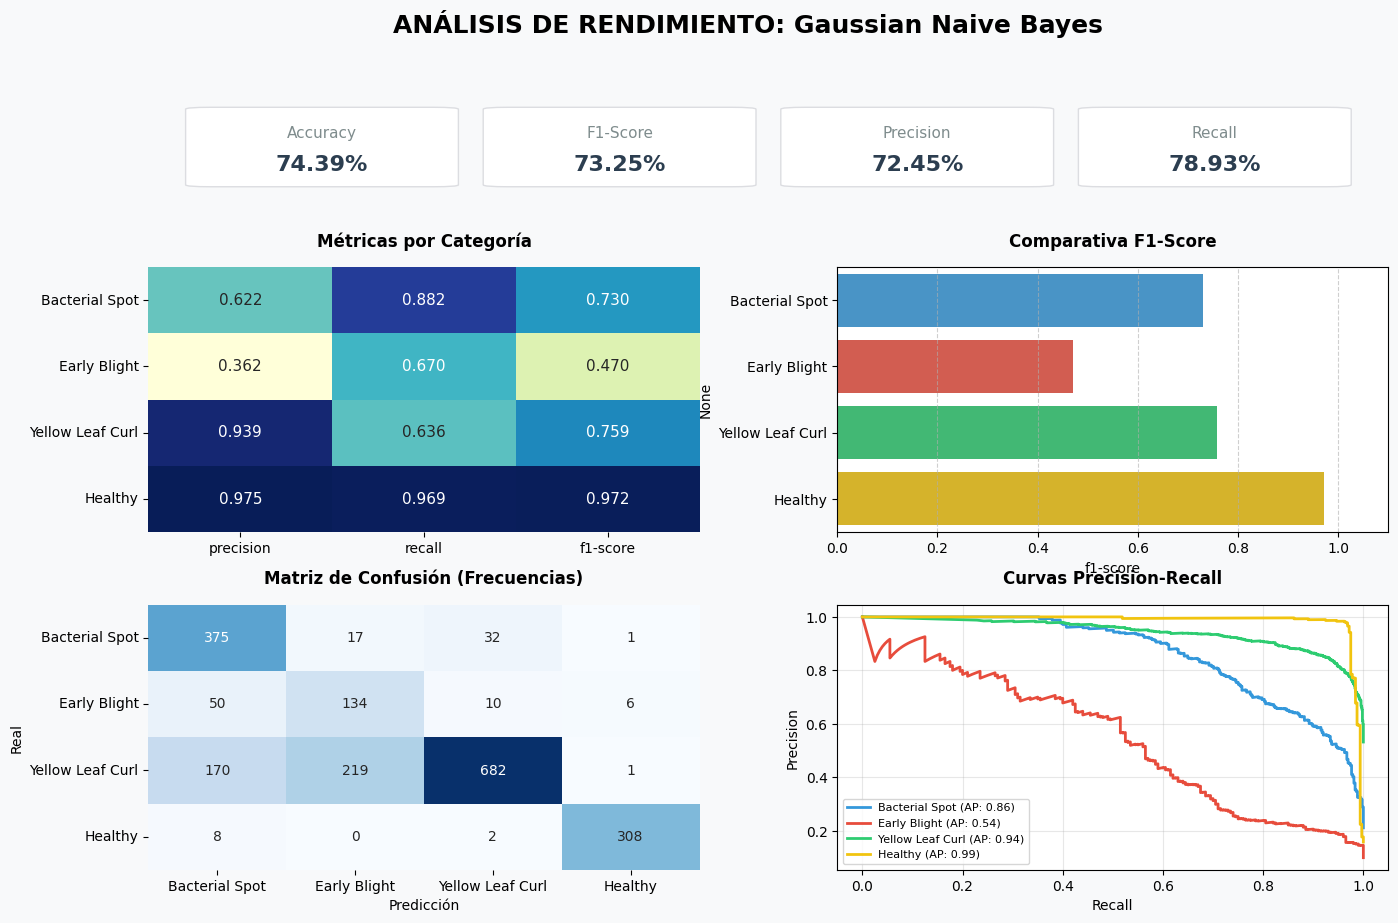

In [ ]:
from sklearn.naive_bayes import GaussianNB

gnb_model = GaussianNB()
resultados_gnb = evaluar_modelo_completo(
    gnb_model, X_train, X_test, y_train, y_test,
    nombre_modelo="Gaussian Naive Bayes"
)

## DT

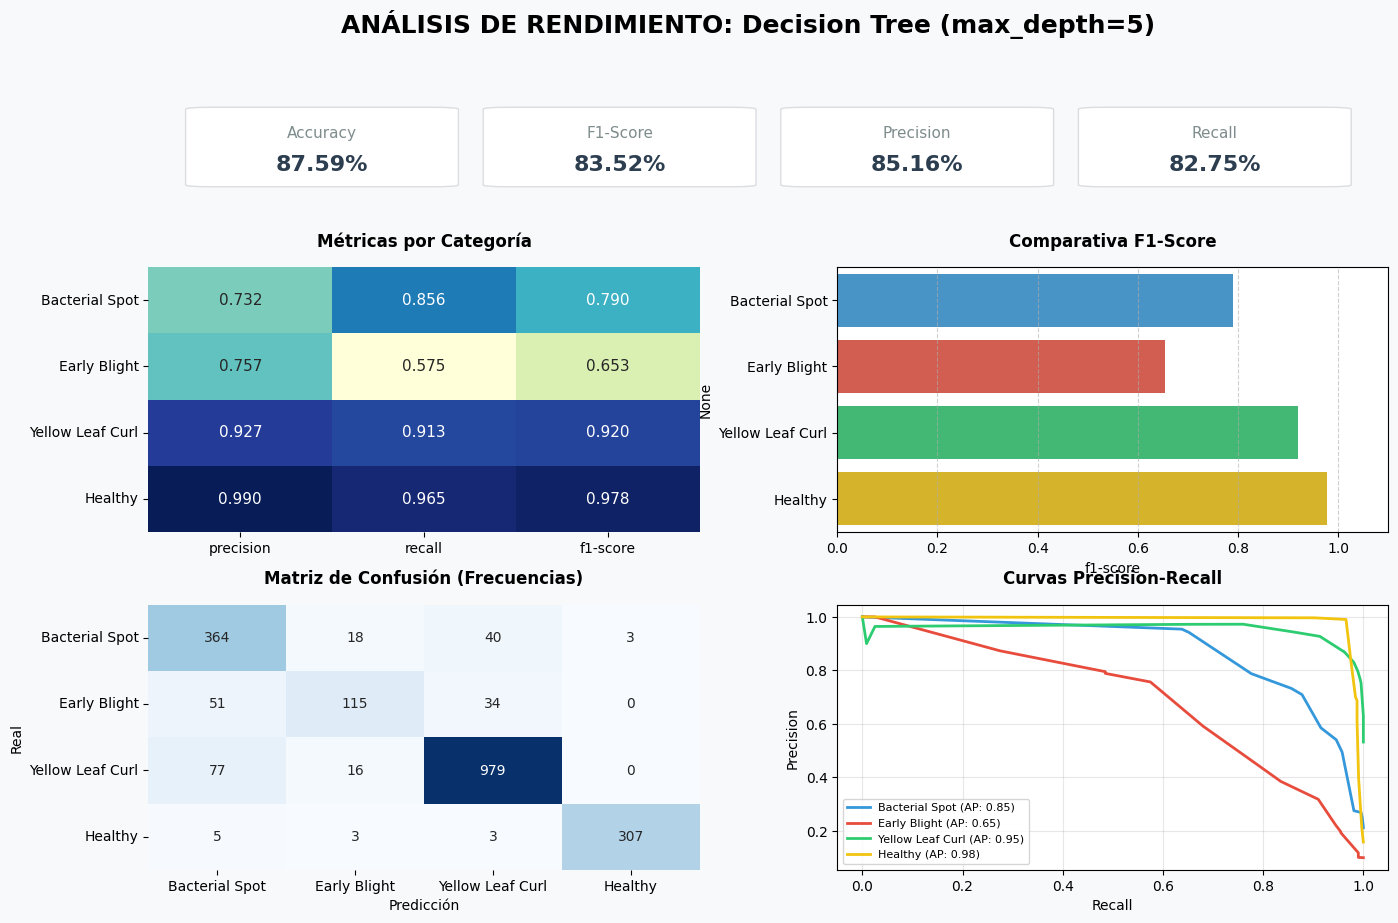

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
resultados_dt = evaluar_modelo_completo(dt_model, X_train, X_test, y_train, y_test,
                                         nombre_modelo="Decision Tree (max_depth=5)")

## Random forest classifier

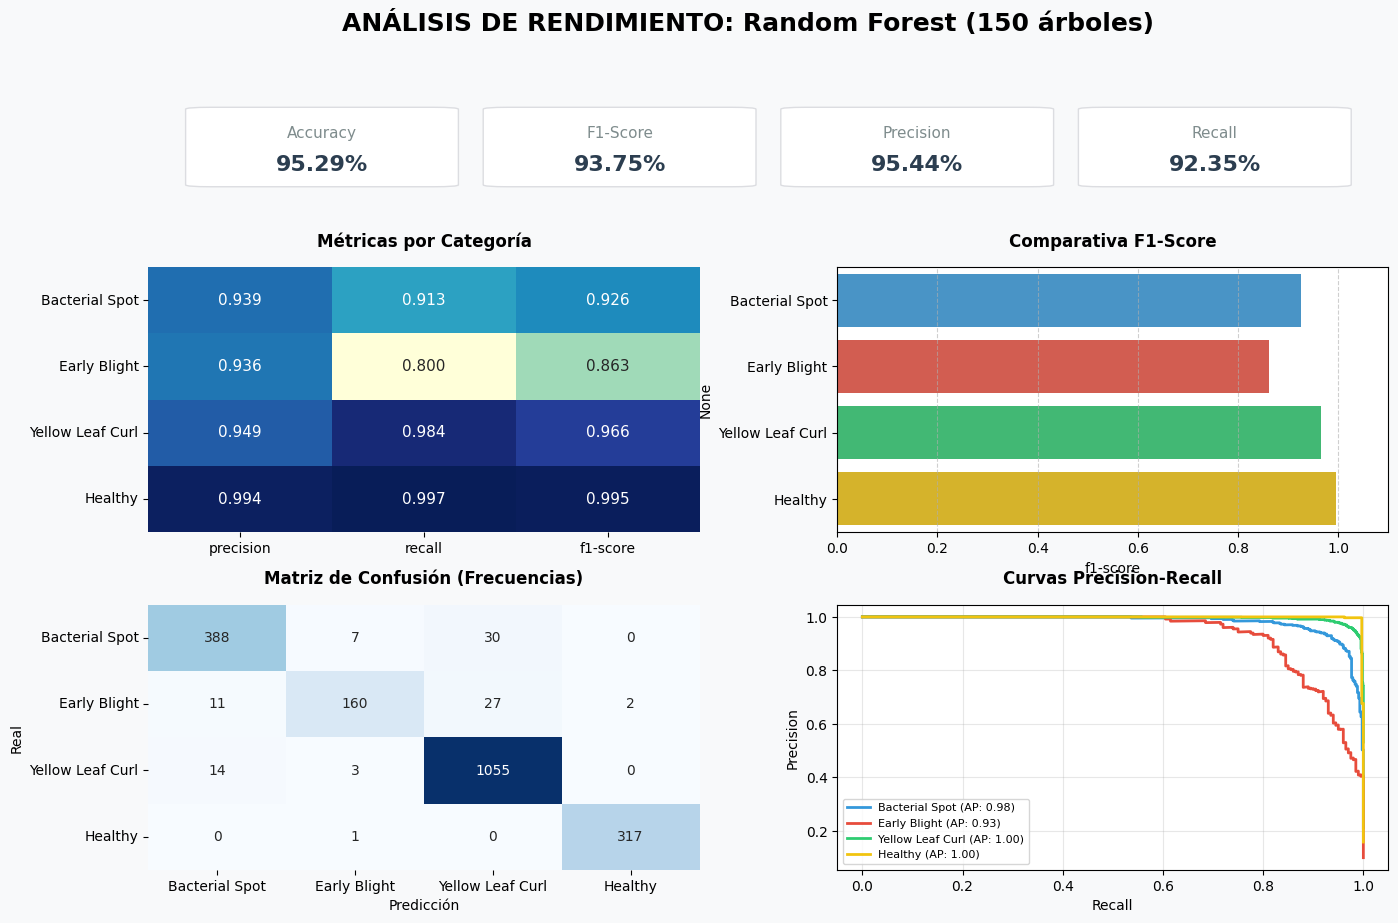

In [ ]:
#@title **code:** working with a Random forest classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=150,      # número de árboles
    max_depth=10,          # profundidad máxima (None = sin límite)
    min_samples_split=5,   # mínimo para dividir un nodo
    random_state=42,
    n_jobs=-1              # usa todos los cores
)
resultados_rf = evaluar_modelo_completo(
    rf_model, X_train, X_test, y_train, y_test,
    nombre_modelo="Random Forest (150 árboles)"
)

## SVM classification

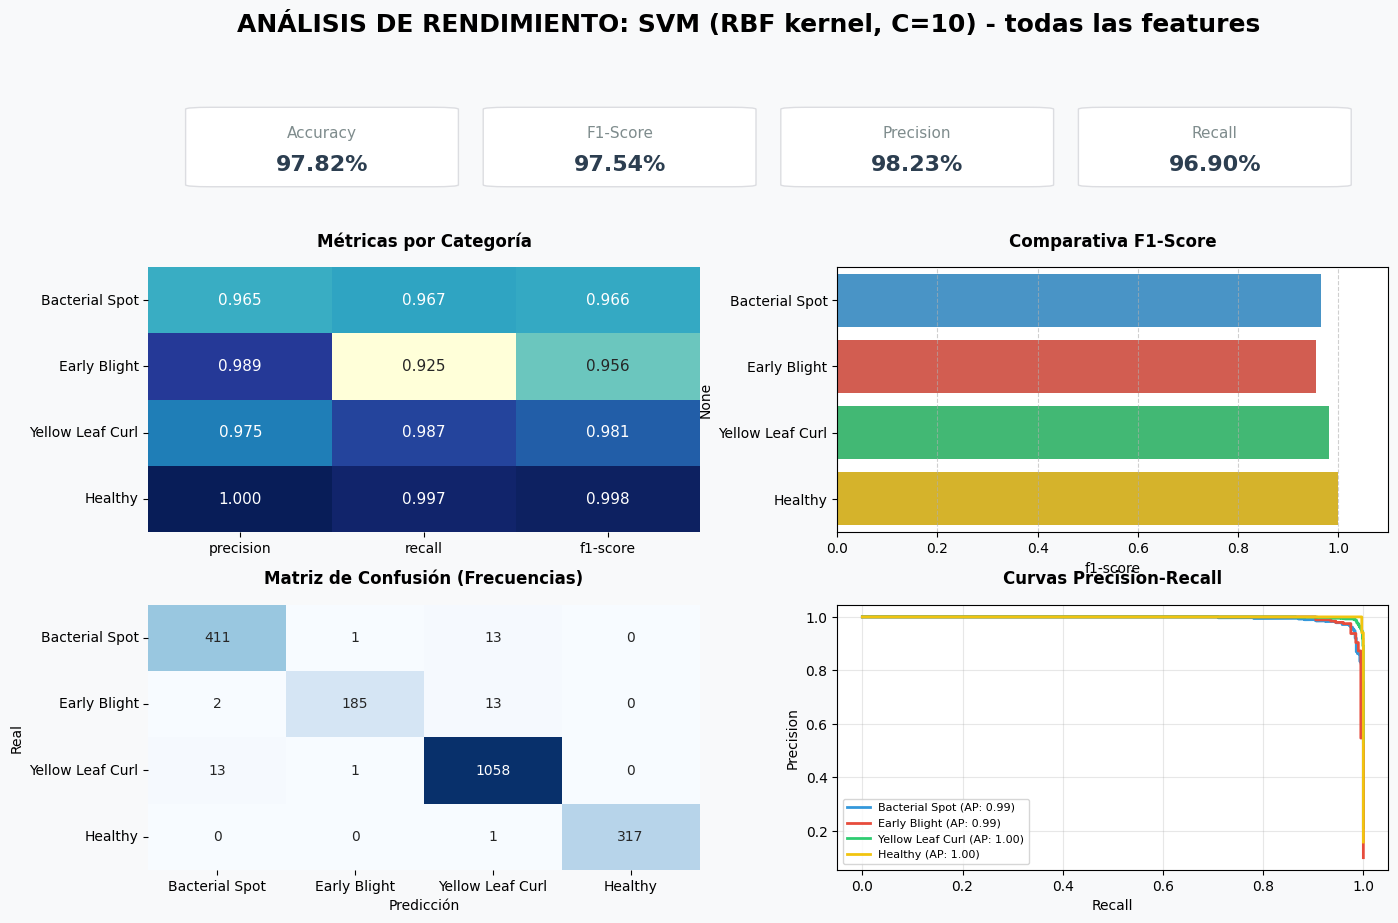

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(
    kernel='rbf',          # kernel radial (no lineal)
    C=10,                  # regularizacion
    gamma='scale',         # parametro del kernel
    probability=True,      # OBLIGATORIO para predict_proba
    random_state=42
)

# Guardamos como _all para preservar al comparar contra SelectKBest mas adelante
resultados_svm_all = evaluar_modelo_completo(
    svm_model, X_train_scaled, X_test_scaled, y_train, y_test,
    nombre_modelo="SVM (RBF kernel, C=10) - todas las features"
)


## Cross validation

COMPARACION DE MODELOS CON 5-FOLD CROSS-VALIDATION

Modelo                         Accuracy             F1-Macro             Recall               Fit Time (s)
--------------------------------------------------------------------------------
Gaussian NB                    0.7323+-0.0089   0.7184+-0.0083   0.7699+-0.0082   0.044
Decision Tree                  0.8686+-0.0031   0.8208+-0.0061   0.8128+-0.0072   0.375
Random Forest                  0.9557+-0.0033   0.9413+-0.0070   0.9295+-0.0077   9.769
SVM (RBF)                      0.9780+-0.0025   0.9724+-0.0035   0.9684+-0.0041   4.021
--------------------------------------------------------------------------------
Mejor modelo por F1-macro: SVM (RBF) (0.9724)


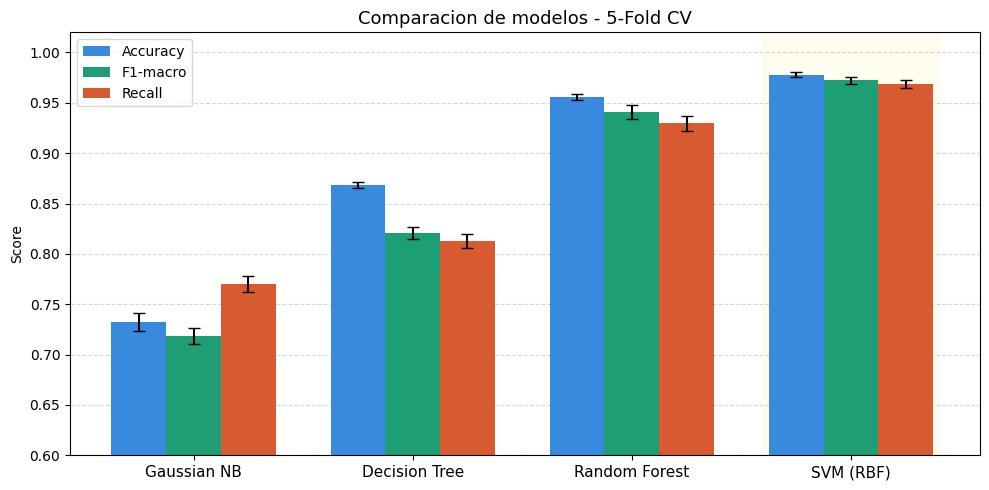

In [ ]:
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt

def comparar_modelos_con_cv(modelos_dict, X_train, y_train, cv=5):
    print("=" * 80)
    print("COMPARACION DE MODELOS CON 5-FOLD CROSS-VALIDATION")
    print("=" * 80)
    print(f"\n{'Modelo':<30} {'Accuracy':<20} {'F1-Macro':<20} {'Recall':<20} {'Fit Time (s)'}")
    print("-" * 80)

    resultados_cv = {}
    for nombre, modelo in modelos_dict.items():
        cv_results = cross_validate(
            modelo, X_train, y_train,
            cv=cv,
            scoring=['accuracy', 'f1_macro', 'recall_macro'],
            return_train_score=True,
            n_jobs=-1
        )
        acc_mean, acc_std = cv_results['test_accuracy'].mean(), cv_results['test_accuracy'].std()
        f1_mean,  f1_std  = cv_results['test_f1_macro'].mean(), cv_results['test_f1_macro'].std()
        rec_mean, rec_std = cv_results['test_recall_macro'].mean(), cv_results['test_recall_macro'].std()
        time_mean = cv_results['fit_time'].mean()

        # FIX BUG: la tabla ahora SI imprime las filas
        print(f"{nombre:<30} {acc_mean:.4f}+-{acc_std:.4f}   {f1_mean:.4f}+-{f1_std:.4f}   "
              f"{rec_mean:.4f}+-{rec_std:.4f}   {time_mean:.3f}")

        resultados_cv[nombre] = {
            'accuracy_mean': acc_mean, 'accuracy_std': acc_std,
            'f1_mean': f1_mean,        'f1_std': f1_std,
            'recall_mean': rec_mean,   'recall_std': rec_std,
            'fit_time': time_mean,     'cv_results': cv_results,
        }

    mejor_modelo = max(resultados_cv.items(), key=lambda x: x[1]['f1_mean'])
    print("-" * 80)
    print(f"Mejor modelo por F1-macro: {mejor_modelo[0]} ({mejor_modelo[1]['f1_mean']:.4f})")

    nombres = list(resultados_cv.keys())
    acc  = [resultados_cv[n]['accuracy_mean'] for n in nombres]
    f1   = [resultados_cv[n]['f1_mean']       for n in nombres]
    rec  = [resultados_cv[n]['recall_mean']   for n in nombres]
    e_acc = [resultados_cv[n]['accuracy_std'] for n in nombres]
    e_f1  = [resultados_cv[n]['f1_std']       for n in nombres]
    e_rec = [resultados_cv[n]['recall_std']   for n in nombres]

    x = np.arange(len(nombres))
    w = 0.25
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - w, acc, w, label='Accuracy', yerr=e_acc, capsize=4, color='#378ADD')
    ax.bar(x,     f1,  w, label='F1-macro', yerr=e_f1,  capsize=4, color='#1D9E75')
    ax.bar(x + w, rec, w, label='Recall',   yerr=e_rec, capsize=4, color='#D85A30')
    ax.set_ylim(0.6, 1.02); ax.set_xticks(x); ax.set_xticklabels(nombres, fontsize=11)
    ax.set_ylabel('Score'); ax.set_title('Comparacion de modelos - 5-Fold CV', fontsize=13)
    ax.legend(); ax.yaxis.grid(True, linestyle='--', alpha=0.5); ax.set_axisbelow(True)

    mejor_idx = nombres.index(mejor_modelo[0])
    ax.axvspan(mejor_idx - 0.4, mejor_idx + 0.4, alpha=0.06, color='gold', zorder=0)
    plt.tight_layout(); plt.show()
    return resultados_cv


modelos = {
    "Gaussian NB":   GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=150, max_depth=15,
                                            min_samples_split=5, random_state=42, n_jobs=-1),
    "SVM (RBF)":     Pipeline([('scaler', StandardScaler()),
                               ('svm', SVC(kernel='rbf', C=10, gamma='scale',
                                           probability=True, random_state=42))])
}

resultados_cv = comparar_modelos_con_cv(modelos, X_train, y_train, cv=5)


# Seleccion de caracterisitcas


F1-macro maximo en CV:  0.9724 (con K=29)
Umbral absoluto:        0.9500
>>> K elegido (minimo K con F1 >= 0.95): 10 / 29


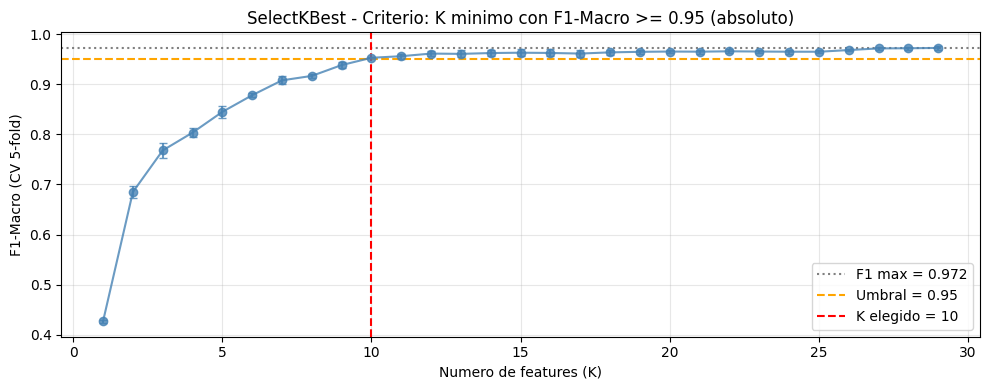


=== Scores de todas las features ===
    feature     score  p_value  seleccionada
correlation 8916.7831      0.0          True
   contrast 3239.7854      0.0          True
      std_S 2756.1769      0.0          True
     mean_S 1995.8711      0.0          True
      std_A 1888.6530      0.0          True
 mean_B_lab 1789.1285      0.0          True
  std_B_lab 1194.1031      0.0          True
     mean_B 1057.5909      0.0          True
     mean_H  924.2418      0.0          True
      std_H  898.7865      0.0          True
        ExG  896.1287      0.0         False
homogeneity  840.5762      0.0         False
      var_G  562.4759      0.0         False
      var_B  537.2199      0.0         False
     mean_A  529.5311      0.0         False
      std_B  497.3660      0.0         False
      std_G  474.8326      0.0         False
      std_L  371.5741      0.0         False
      std_V  356.3284      0.0         False
     energy  355.9437      0.0         False
     mean_V  340.

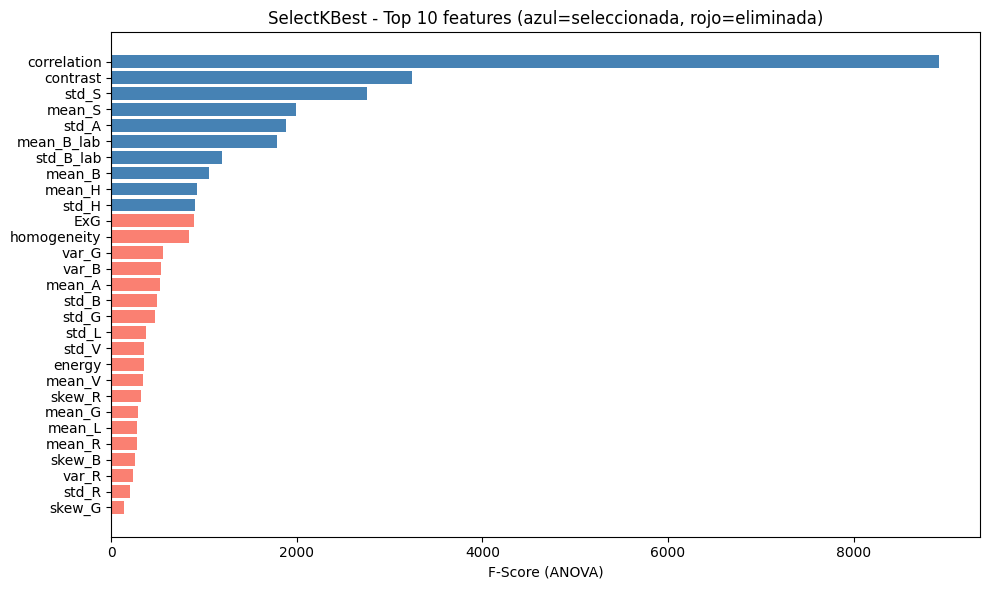

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
import pandas as pd
import matplotlib.pyplot as plt

# Config UNICA del SVM (se usa en barrido Y en evaluacion final)
SVC_CONFIG = dict(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)

scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_train)
X_te_sc = scaler.transform(X_test)

# 1. Barrido de K
resultados_k = []
for k in range(1, X_train.shape[1] + 1):
    sel   = SelectKBest(f_classif, k=k)
    X_sel = sel.fit_transform(X_tr_sc, y_train)
    cv    = cross_val_score(
                SVC(**{**SVC_CONFIG, 'probability': False}),
                X_sel, y_train, cv=5, scoring='f1_macro', n_jobs=-1
            )
    resultados_k.append({'k': k, 'f1_macro_cv': cv.mean(), 'f1_std': cv.std()})

df_k = pd.DataFrame(resultados_k)

# 2. CRITERIO: K minimo tal que F1 >= 0.95 (absoluto)
UMBRAL     = 0.95
f1_max     = df_k['f1_macro_cv'].max()
k_argmax   = int(df_k.loc[df_k['f1_macro_cv'].idxmax(), 'k'])
candidatos = df_k[df_k['f1_macro_cv'] >= UMBRAL]
k_optimo   = int(candidatos['k'].min()) if not candidatos.empty else k_argmax

print(f"F1-macro maximo en CV:  {f1_max:.4f} (con K={k_argmax})")
print(f"Umbral absoluto:        {UMBRAL:.4f}")
print(f">>> K elegido (minimo K con F1 >= {UMBRAL}): {k_optimo} / {X_train.shape[1]}")

# 3. Grafica K vs F1
fig, ax = plt.subplots(figsize=(10, 4))
ax.errorbar(df_k['k'], df_k['f1_macro_cv'], yerr=df_k['f1_std'],
            marker='o', color='steelblue', alpha=0.8, capsize=3)
ax.axhline(f1_max,   color='gray',   linestyle=':',  label=f'F1 max = {f1_max:.3f}')
ax.axhline(UMBRAL,   color='orange', linestyle='--', label=f'Umbral = {UMBRAL:.2f}')
ax.axvline(k_optimo, color='red',    linestyle='--', label=f'K elegido = {k_optimo}')
ax.set_xlabel('Numero de features (K)')
ax.set_ylabel('F1-Macro (CV 5-fold)')
ax.set_title('SelectKBest - Criterio: K minimo con F1-Macro >= 0.95 (absoluto)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

# 4. Ajustar selector final
selector_final = SelectKBest(f_classif, k=k_optimo)
selector_final.fit(X_tr_sc, y_train)

scores_df = pd.DataFrame({
    'feature':      X_train.columns,
    'score':        selector_final.scores_,
    'p_value':      selector_final.pvalues_,
    'seleccionada': selector_final.get_support()
}).sort_values('score', ascending=False).reset_index(drop=True)

print("\n=== Scores de todas las features ===")
print(scores_df.round(4).to_string(index=False))

features_sel = X_train.columns[selector_final.get_support()].tolist()
features_eli = X_train.columns[~selector_final.get_support()].tolist()
print(f"\nSELECCIONADAS ({len(features_sel)}): {features_sel}")
print(f"ELIMINADAS    ({len(features_eli)}): {features_eli}")

scores_plot = scores_df.sort_values('score')
colors      = ['steelblue' if s else 'salmon' for s in scores_plot['seleccionada']]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(scores_plot['feature'], scores_plot['score'], color=colors)
ax.set_xlabel('F-Score (ANOVA)')
ax.set_title(f'SelectKBest - Top {k_optimo} features (azul=seleccionada, rojo=eliminada)')
plt.tight_layout(); plt.show()


## Evaluacion final con K elegido automaticamente

Usamos el K seleccionado arriba (minimo K con F1 >= 0.95 absoluto) y el mismo SVC que se uso en el barrido.



Entrenando SVM final con K=10 features (criterio: F1 >= 95% absoluto)


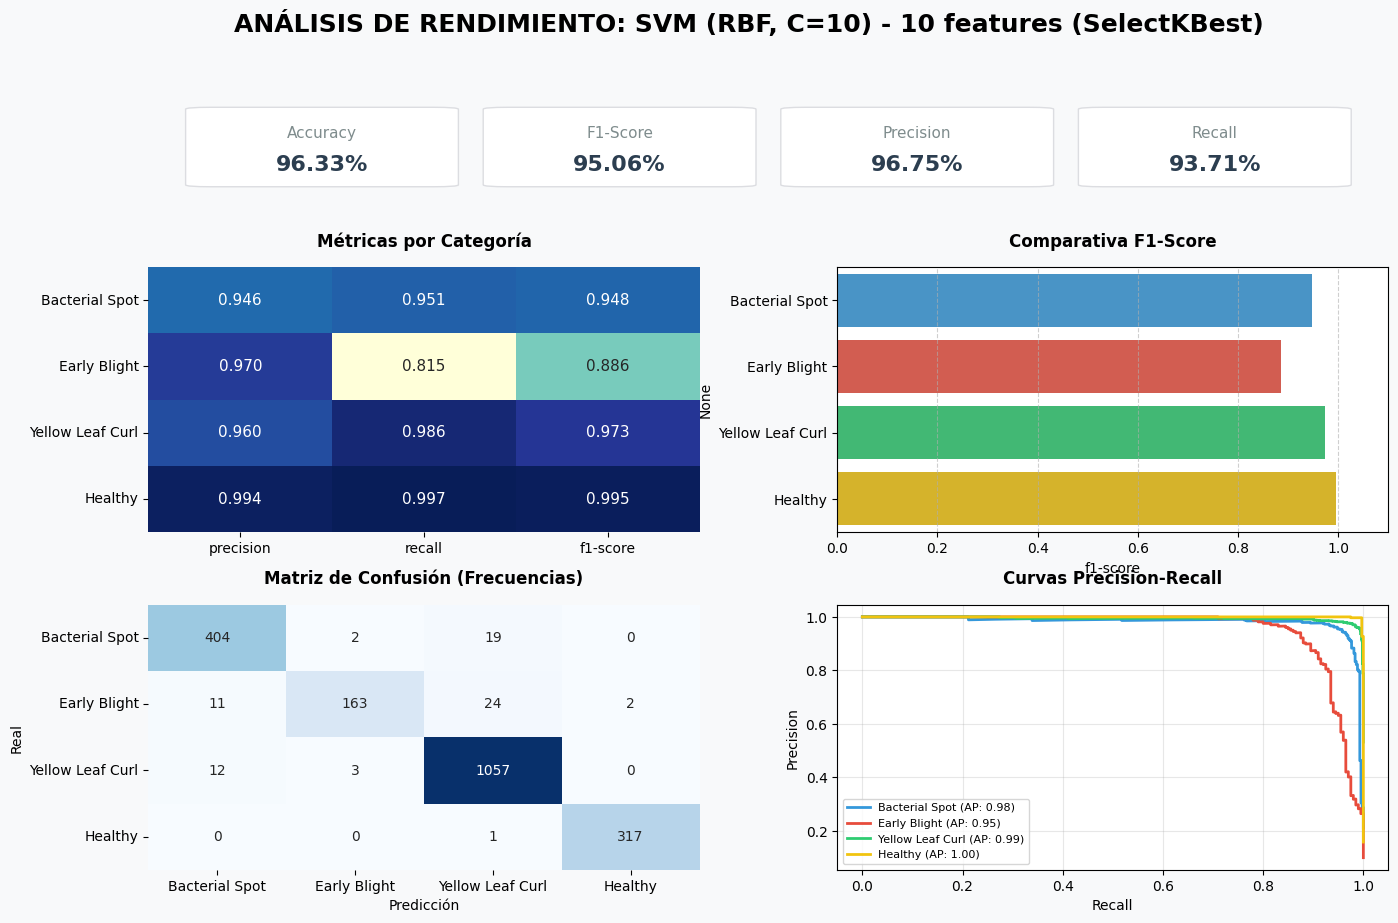

In [ ]:
# Usamos el k_optimo y SVC_CONFIG definidos en la celda anterior
print(f"Entrenando SVM final con K={k_optimo} features (criterio: F1 >= 95% absoluto)")

X_train_sel = selector_final.transform(X_tr_sc)
X_test_sel  = selector_final.transform(X_te_sc)

svm_model_sel = SVC(**SVC_CONFIG)

# Guardamos como _sel para distinguir del _all (todas las features)
resultados_svm_sel = evaluar_modelo_completo(
    svm_model_sel, X_train_sel, X_test_sel, y_train, y_test,
    nombre_modelo=f"SVM (RBF, C={SVC_CONFIG['C']}) - {k_optimo} features (SelectKBest)"
)


## Comparativa final (con SVM-SelectKBest)


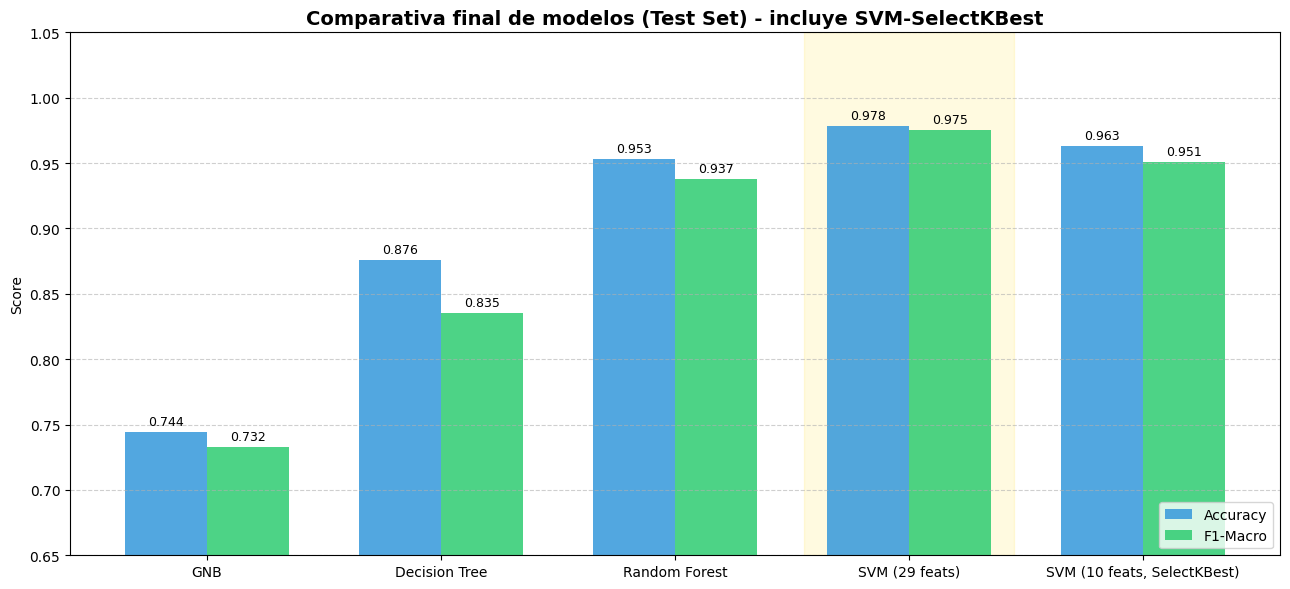


Mejor modelo por F1-macro en test: SVM (29 feats) (0.9754)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Comparativa final con los 5 modelos entrenados (incluyendo SVM-SelectKBest)
model_names = ["GNB", "Decision Tree", "Random Forest",
               "SVM (29 feats)", f"SVM ({k_optimo} feats, SelectKBest)"]

# F1-macro por modelo (saca 'macro avg' del classification_report)
def f1_macro(rep):
    return rep.loc['macro avg', 'f1-score'] if 'macro avg' in rep.index else rep['f1-score'].mean()

f1_scores = [
    f1_macro(resultados_gnb),
    f1_macro(resultados_dt),
    f1_macro(resultados_rf),
    f1_macro(resultados_svm_all),
    f1_macro(resultados_svm_sel),
]

# Accuracy en el test set
accuracy_scores = [
    accuracy_score(y_test, gnb_model.predict(X_test)),
    accuracy_score(y_test, dt_model.predict(X_test)),
    accuracy_score(y_test, rf_model.predict(X_test)),
    accuracy_score(y_test, svm_model.predict(X_test_scaled)),
    accuracy_score(y_test, svm_model_sel.predict(X_test_sel)),
]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(13, 6))
rects1 = ax.bar(x - width/2, accuracy_scores, width, label='Accuracy', color='#3498db', alpha=0.85)
rects2 = ax.bar(x + width/2, f1_scores,       width, label='F1-Macro', color='#2ecc71', alpha=0.85)

ax.set_ylabel('Score')
ax.set_title('Comparativa final de modelos (Test Set) - incluye SVM-SelectKBest',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=10)
ax.set_ylim(0.65, 1.05)
ax.legend(loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.6)

def autolabel(rects):
    for rect in rects:
        h = rect.get_height()
        ax.annotate(f'{h:.3f}', xy=(rect.get_x() + rect.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1); autolabel(rects2)

mejor_idx = int(np.argmax(f1_scores))
ax.axvspan(mejor_idx - 0.45, mejor_idx + 0.45, color='gold', alpha=0.12, zorder=0)

plt.tight_layout(); plt.show()

print(f"\nMejor modelo por F1-macro en test: {model_names[mejor_idx]} ({f1_scores[mejor_idx]:.4f})")


### Curvas de Aprendizaje para el SVM (RBF) con las características seleccionadas

In [ ]:
# fig, axes = plt.subplots(1, 1, figsize=(10, 5))
# plot_learning_curve(
#     svm_model_sel,
#     f"Curva de Aprendizaje - SVM RBF + SelectKBest (K={k_optimo})",
#     X_train_sel, y_train,
#     axes=[axes], ylim=(0.5, 1.01), cv=5, n_jobs=-1, scoring='f1_macro'
# )
# plt.tight_layout(); plt.show()


### Curvas de Aprendizaje para Gaussian Naive Bayes

In [ ]:
# fig, axes = plt.subplots(1, 1, figsize=(10, 5))
# plot_learning_curve(
#     gnb_model, "Curva de Aprendizaje - Gaussian Naive Bayes",
#     X_train, y_train,
#     axes=[axes], ylim=(0.5, 1.01), cv=5, n_jobs=-1, scoring='f1_macro'
# )
# plt.tight_layout(); plt.show()


### Curvas de Aprendizaje para Decision Tree

In [ ]:
# fig, axes = plt.subplots(1, 1, figsize=(10, 5))
# plot_learning_curve(
#     dt_model, "Curva de Aprendizaje - Decision Tree (max_depth=5)",
#     X_train, y_train,
#     axes=[axes], ylim=(0.5, 1.01), cv=5, n_jobs=-1, scoring='f1_macro'
# )
# plt.tight_layout(); plt.show()


### Curvas de Aprendizaje para Random Forest

In [ ]:
# fig, axes = plt.subplots(1, 1, figsize=(10, 5))
# plot_learning_curve(
#     rf_model, "Curva de Aprendizaje - Random Forest",
#     X_train, y_train,
#     axes=[axes], ylim=(0.5, 1.01), cv=5, n_jobs=-1, scoring='f1_macro'
# )
# plt.tight_layout(); plt.show()


# DEEP LEARNING

Model: "DNN_Tomato"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,500 (64.45 KB)

 Trainable params: 16,500 (64.45 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.7704 - loss: 0.5798 - val_accuracy: 0.8701 - val_loss: 0.3597 - learning_rate: 0.0010
Epoch 2/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8848 - loss: 0.3232 - val_accuracy: 0.9214 - val_loss: 0.2314 - learning_rate: 0.0010
Epoch 3/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9168 - loss: 0.2403 - val_accuracy: 0.9305 - val_loss: 0.1987 - learning_rate: 0.0010
Epoch 4/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9301 - loss: 0.2107 - val_accuracy: 0.9347 - val_loss: 0.1849 - learning_rate: 0.0010
Epoch 5/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9318 - loss: 0.1980 - val_accuracy: 0.9371 - val_loss: 0.1843 - learning_rate: 0.0010
Epoch 6/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9355 - loss: 0.1846 - val_accuracy: 0.9471 - val_loss: 0.1651 - learning_rate: 0.0010
Epoch 7/50
215/215 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9409 - loss: 0.1741 -

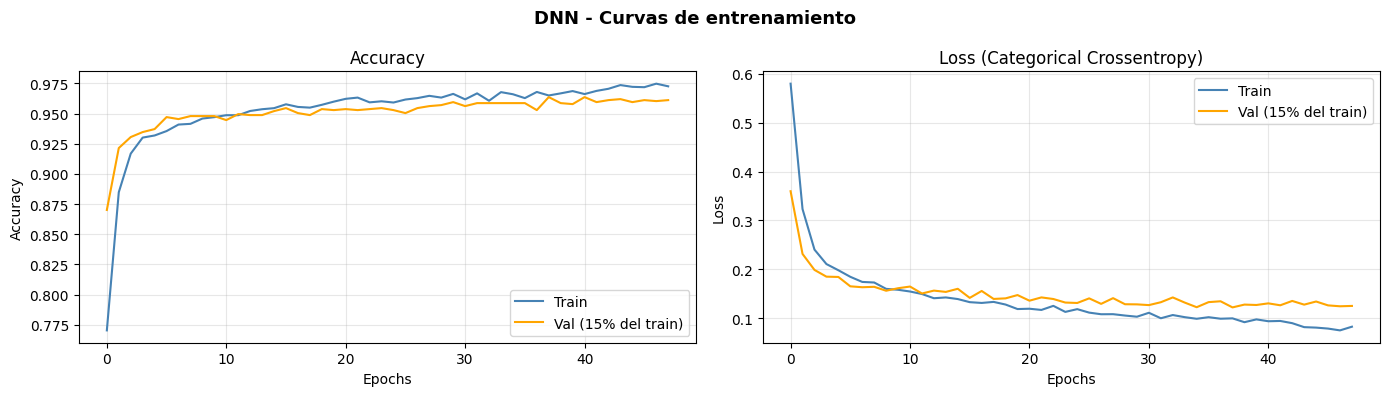

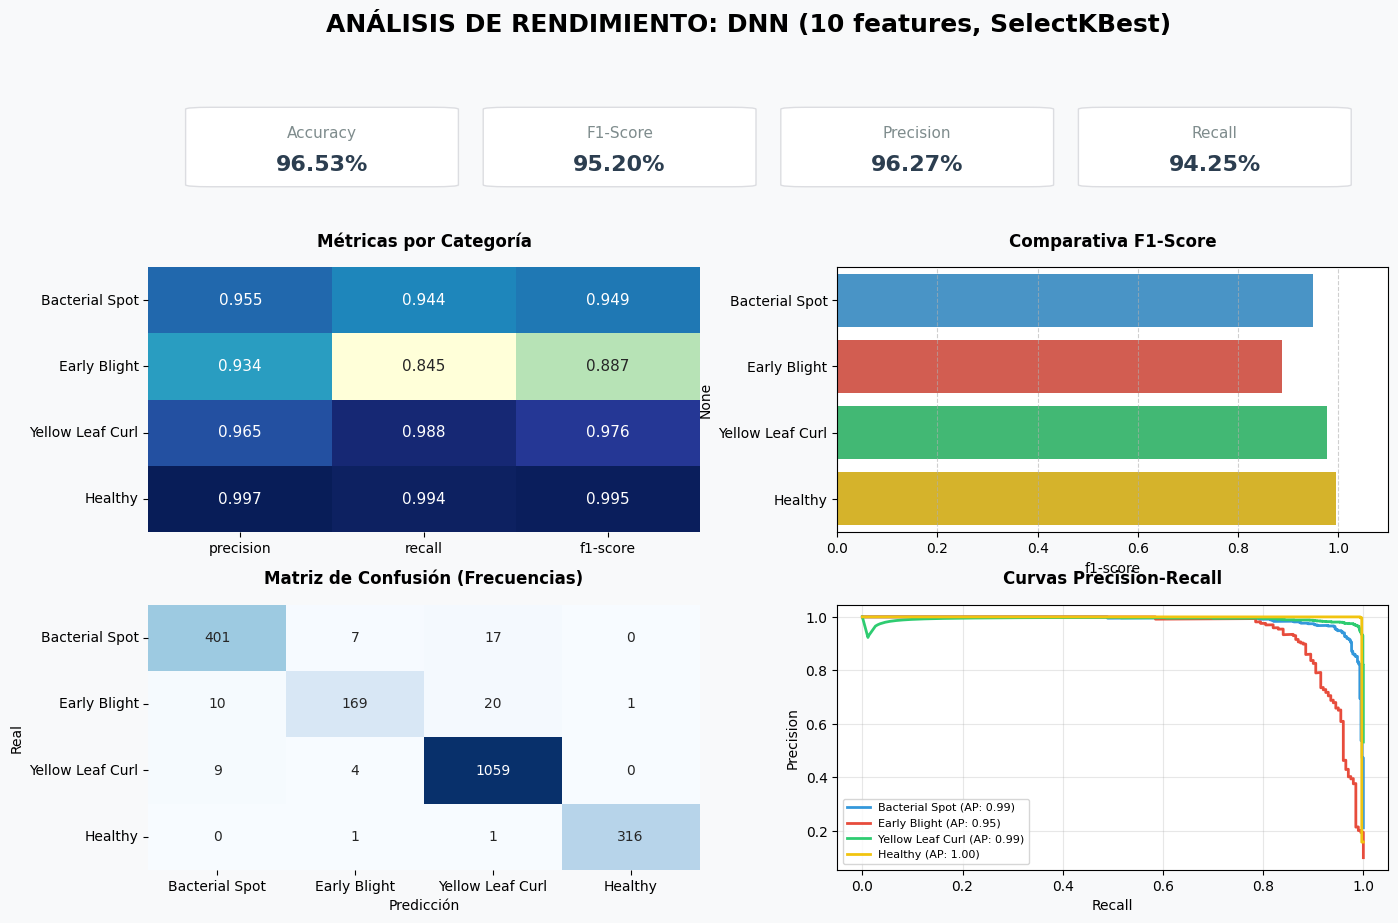

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# 1. One-Hot Encoding
le          = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)
n_clases    = len(le.classes_)
y_train_ohe = to_categorical(y_train_enc, num_classes=n_clases)
y_test_ohe  = to_categorical(y_test_enc,  num_classes=n_clases)

# 2. Arquitectura DNN -- Input shape dinamico segun K elegido
n_features = X_train_sel.shape[1]
model = tf.keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(n_clases, activation='softmax')
], name="DNN_Tomato")

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

# 3. Entrenar -- FIX: usar validation_split del train, NO el test set
# (antes: validation_data=(X_test_sel, y_test_ohe) -> leakage)
history = model.fit(
    X_train_sel, y_train_ohe,
    epochs=50, batch_size=32,
    validation_split=0.15,
    callbacks=callbacks, verbose=1
)

# 4. Curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('DNN - Curvas de entrenamiento', fontsize=13, weight='bold')
axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val (15% del train)', color='orange')
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('Accuracy'); axes[0].set_title('Accuracy')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val (15% del train)', color='orange')
axes[1].set_xlabel('Epochs'); axes[1].set_ylabel('Loss'); axes[1].set_title('Loss (Categorical Crossentropy)')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 5. Evaluar sobre el TEST set (limpio, no se uso para EarlyStopping)
class KerasWrapper:
    def __init__(self, keras_model, label_encoder):
        self.model_   = keras_model
        self.le_      = label_encoder
        self.classes_ = label_encoder.classes_
    def fit(self, X, y): pass
    def predict(self, X):
        proba = self.model_.predict(X, verbose=0)
        return self.le_.inverse_transform(np.argmax(proba, axis=1))
    def predict_proba(self, X):
        return self.model_.predict(X, verbose=0)

dnn_wrapper = KerasWrapper(model, le)
resultados_dnn = evaluar_modelo_completo(
    dnn_wrapper, X_train_sel, X_test_sel, y_train, y_test,
    nombre_modelo=f"DNN ({n_features} features, SelectKBest)"
)


# Aprendizaje No Supervisado y Reducción de DimensiónEn esta sección aplicamos técnicas vistas en clase para responder preguntasadicionales sobre nuestro conjunto de características:

1. **PCA (Análisis de Componentes Principales):** ¿Cuántas dimensiones realmente   necesitamos? Muchas de nuestras features GLCM (contraste, homogeneidad, etc.)   se calculan en 4 ángulos distintos y están altamente correlacionadas entre sí,   por lo que PCA debería poder comprimir esta redundancia.
2. **t-SNE:** Visualizar en 2D si las clases de enfermedad son intrínsecamente   separables con las features extraídas.
3. **K-Means (no supervisado):** ¿Las features capturan estructura de enfermedad   incluso *sin* usar las etiquetas? Comparamos los clusters obtenidos contra las   etiquetas reales con el Adjusted Rand Index (ARI).

## 1. PCA — Varianza explicada acumuladaPrimero estandarizamos las features (PCA es sensible a escala) y graficamos lavarianza explicada acumulada en función del número de componentes. Esto nos dicecuántas componentes hacen falta para conservar, por ejemplo, el 95% de lainformación.

Componentes para 90% de varianza: 7 / 29
Componentes para 95% de varianza: 8 / 29
Componentes para 99% de varianza: 14 / 29


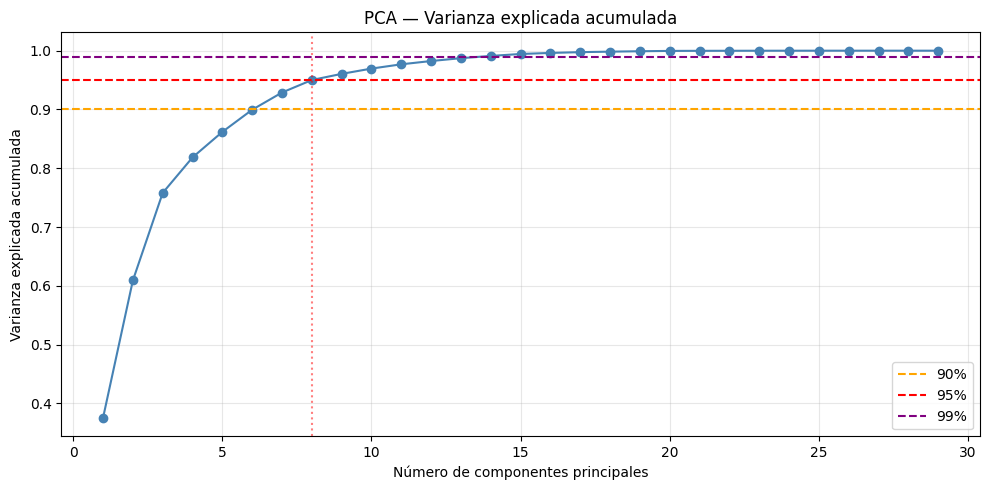

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Estandarización (PCA es sensible a la escala)
scaler_pca = StandardScaler()
X_train_sc = scaler_pca.fit_transform(X_train)
X_test_sc  = scaler_pca.transform(X_test)

# PCA con todas las componentes para ver la curva completa
pca_full = PCA().fit(X_train_sc)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)

# Número de componentes para distintos umbrales
n_90 = int(np.argmax(var_acum >= 0.90) + 1)
n_95 = int(np.argmax(var_acum >= 0.95) + 1)
n_99 = int(np.argmax(var_acum >= 0.99) + 1)

print(f"Componentes para 90% de varianza: {n_90} / {X_train.shape[1]}")
print(f"Componentes para 95% de varianza: {n_95} / {X_train.shape[1]}")
print(f"Componentes para 99% de varianza: {n_99} / {X_train.shape[1]}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(var_acum) + 1), var_acum, marker='o', color='steelblue')
ax.axhline(0.90, color='orange',  linestyle='--', label='90%')
ax.axhline(0.95, color='red',     linestyle='--', label='95%')
ax.axhline(0.99, color='purple',  linestyle='--', label='99%')
ax.axvline(n_95, color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('Número de componentes principales')
ax.set_ylabel('Varianza explicada acumulada')
ax.set_title('PCA — Varianza explicada acumulada')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2. PCA — Visualización en 2D y 3DProyectamos los datos a las 2 y 3 primeras componentes principales para observar si las clases se separan en este espacio reducido.

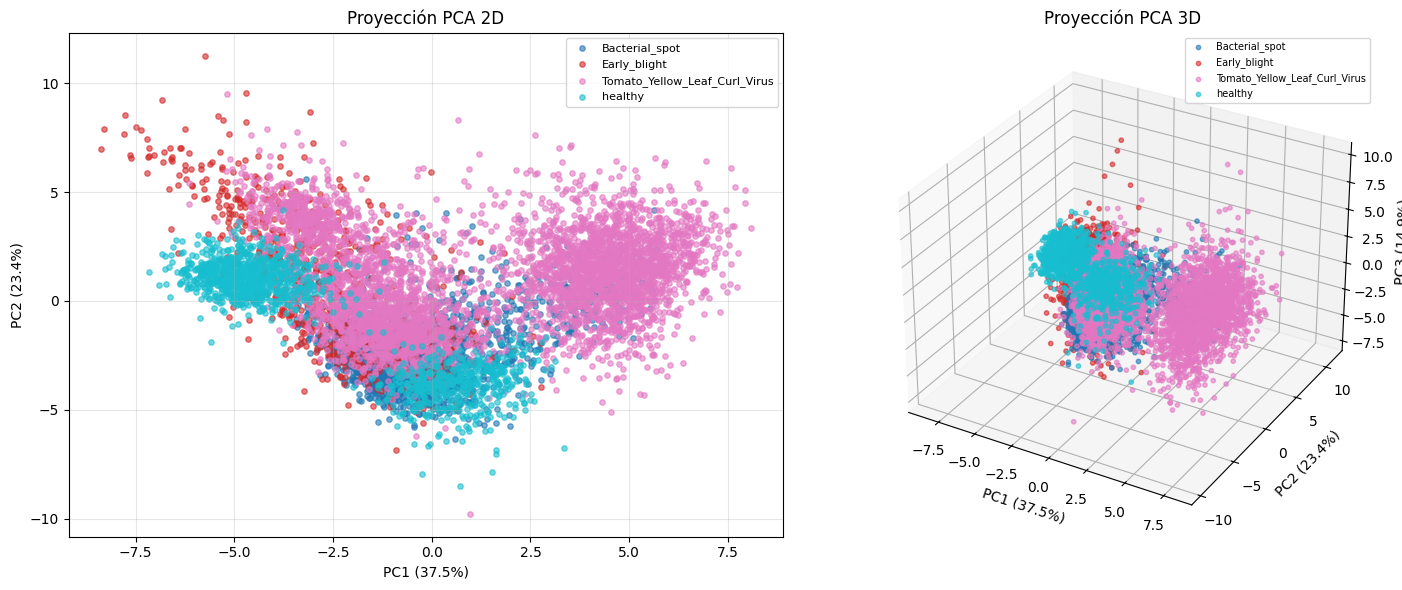

Varianza explicada por las 3 primeras PC: 75.80%


In [ ]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

pca_2d = PCA(n_components=2).fit(X_train_sc)
X_train_2d = pca_2d.transform(X_train_sc)

pca_3d = PCA(n_components=3).fit(X_train_sc)
X_train_3d = pca_3d.transform(X_train_sc)

clases = sorted(y_train.unique())
colores = plt.cm.tab10(np.linspace(0, 1, len(clases)))

fig = plt.figure(figsize=(15, 6))

# 2D
ax1 = fig.add_subplot(1, 2, 1)
for clase, color in zip(clases, colores):
    m = (y_train.values == clase)
    ax1.scatter(X_train_2d[m, 0], X_train_2d[m, 1],
                c=[color], label=clase.replace('Tomato___', ''),
                alpha=0.6, s=15)
ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
ax1.set_title('Proyección PCA 2D')
ax1.legend(fontsize=8, loc='best')
ax1.grid(alpha=0.3)

# 3D
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
for clase, color in zip(clases, colores):
    m = (y_train.values == clase)
    ax2.scatter(X_train_3d[m, 0], X_train_3d[m, 1], X_train_3d[m, 2],
                c=[color], label=clase.replace('Tomato___', ''),
                alpha=0.6, s=10)
ax2.set_xlabel(f'PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)')
ax2.set_ylabel(f'PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)')
ax2.set_zlabel(f'PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)')
ax2.set_title('Proyección PCA 3D')
ax2.legend(fontsize=7, loc='best')

plt.tight_layout()
plt.show()

print(f"Varianza explicada por las 3 primeras PC: "
      f"{pca_3d.explained_variance_ratio_.sum()*100:.2f}%")

## 3. PCA + Clasificadores — ¿pierde rendimiento usar menos dimensiones?Reentrenamos SVM, Random Forest y Gaussian NB usando los datos reducidos con PCA(95% de varianza) y comparamos contra el rendimiento con todas las featuresescaladas. Este es el mismo experimento del notebook de clase aplicado a nuestrodataset.

Comparacion con 5-fold CV (F1-macro):

       Modelo  F1 (sin PCA)  F1 (PCA 90%)  F1 (PCA 95%)  F1 (PCA 99%)
    SVM (RBF)        0.9724        0.9140        0.9401        0.9644
Random Forest        0.9402        0.8984        0.9153        0.9416
  Gaussian NB        0.7128        0.7996        0.8126        0.8373

Componentes por umbral: {0.9: 7, 0.95: 8, 0.99: 14}


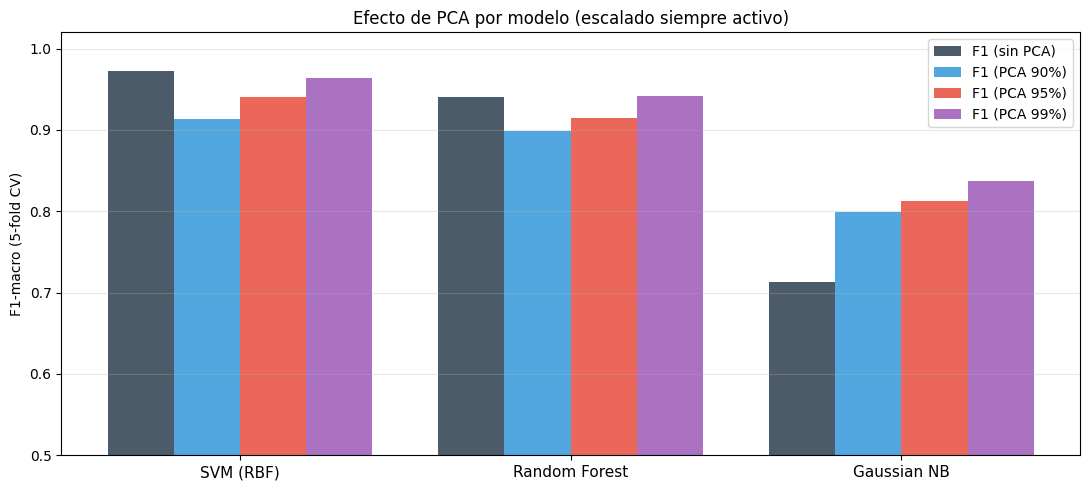

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Comparacion con CV (5-fold) en lugar de un solo split (que era ruidoso)
# y con multiples umbrales de varianza PCA
THRESHOLDS = [0.90, 0.95, 0.99]

modelos_base = {
    'SVM (RBF)':     SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gaussian NB':   GaussianNB(),
}

filas = []
for nombre, modelo in modelos_base.items():
    # Baseline justo: escalado + modelo, SIN PCA (mismo preprocessing que con PCA)
    pipe_full = Pipeline([('scaler', StandardScaler()), ('clf', modelo)])
    f1_full   = cross_val_score(pipe_full, X_train, y_train, cv=5,
                                scoring='f1_macro', n_jobs=-1).mean()
    fila = {'Modelo': nombre, 'F1 (sin PCA)': f1_full}

    for t in THRESHOLDS:
        pipe_pca = Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=t, random_state=42)),
            ('clf', modelo),
        ])
        f1_pca = cross_val_score(pipe_pca, X_train, y_train, cv=5,
                                  scoring='f1_macro', n_jobs=-1).mean()
        fila[f'F1 (PCA {int(t*100)}%)'] = f1_pca

    filas.append(fila)

df_pca = pd.DataFrame(filas)
print("Comparacion con 5-fold CV (F1-macro):\n")
print(df_pca.round(4).to_string(index=False))

# Mostrar cuantas componentes salen con cada umbral
pca_diag = PCA().fit(StandardScaler().fit_transform(X_train))
var_acum = np.cumsum(pca_diag.explained_variance_ratio_)
n_comps  = {t: int(np.argmax(var_acum >= t) + 1) for t in THRESHOLDS}
print(f"\nComponentes por umbral: {n_comps}")

# Grafica comparativa
fig, ax = plt.subplots(figsize=(11, 5))
nombres = df_pca['Modelo'].tolist()
x = np.arange(len(nombres))
w = 0.2
cols = ['F1 (sin PCA)'] + [f'F1 (PCA {int(t*100)}%)' for t in THRESHOLDS]
colores = ['#2C3E50', '#3498db', '#e74c3c', '#9b59b6']
for i, (col, color) in enumerate(zip(cols, colores)):
    ax.bar(x + (i - 1.5) * w, df_pca[col], w, label=col, color=color, alpha=0.85)

ax.set_xticks(x); ax.set_xticklabels(nombres, fontsize=11)
ax.set_ylabel('F1-macro (5-fold CV)'); ax.set_ylim(0.5, 1.02)
ax.set_title('Efecto de PCA por modelo (escalado siempre activo)')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


## 4. t-SNE — Visualización no lineal de separabilidad. A diferencia de PCA (lineal), t-SNE preserva relaciones de vecindad locales y suele revelar estructura de clases más claramente. Lo aplicamos sobre lasfeatures estandarizadas para visualizar cuán separables son las 4 clases. t-SNE es costoso.

In [ ]:
# !pip install cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com

In [ ]:
# from cuml.manifold import TSNE
# import cupy as cp

# # El resto del código queda IGUAL, cuML imita la API de sklearn
# tsne = TSNE(
#     n_components=2,
#     perplexity=30,
#     learning_rate=200,
#     init='pca',
#     random_state=42,
# )

# X_tsne = tsne.fit_transform(X_train_sc)  # misma línea que antes

# fig, ax = plt.subplots(figsize=(9, 7))
# for clase, color in zip(clases, colores):
#     m = (y_tsne_input == clase)
#     ax.scatter(X_tsne[m, 0], X_tsne[m, 1],
#                c=[color], label=clase.replace('Tomato___', ''),
#                alpha=0.7, s=18)
# ax.set_xlabel('t-SNE 1')
# ax.set_ylabel('t-SNE 2')
# ax.set_title('t-SNE (2D) sobre features estandarizadas')
# ax.legend(fontsize=9)
# ax.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()

Muestreando 2000 de 8060 para t-SNE


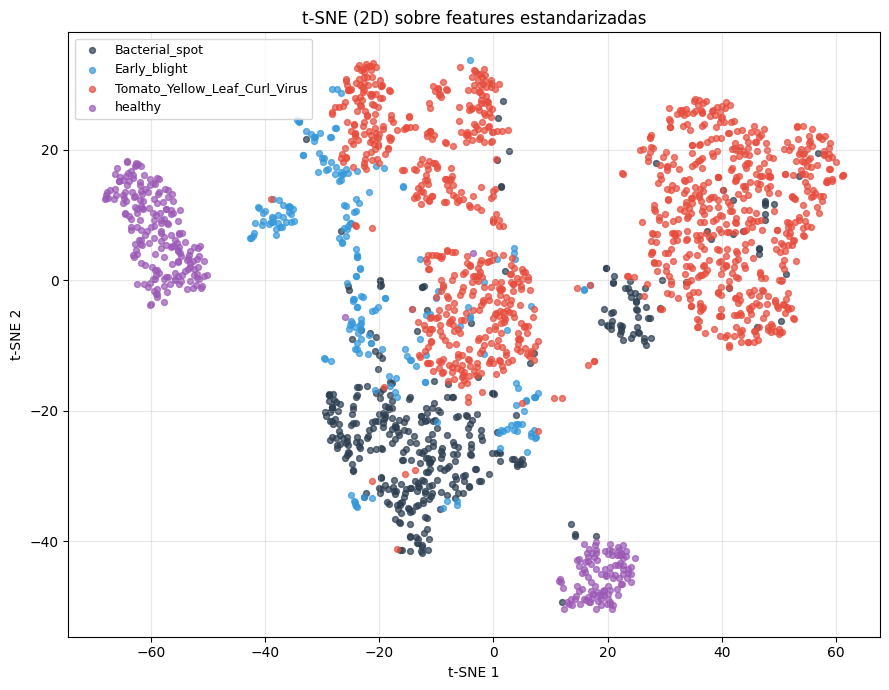

In [ ]:
# from sklearn.manifold import TSNE

# print(f"Ejecutando t-SNE sobre {X_train_sc.shape[0]} muestras (puede tardar varios minutos)...")

# tsne = TSNE(
#     n_components=2,
#     perplexity=30,
#     learning_rate='auto',
#     init='pca',
#     random_state=42,
#     n_jobs=-1,
# )
# X_tsne = tsne.fit_transform(X_tsne_input)

# fig, ax = plt.subplots(figsize=(9, 7))
# for clase, color in zip(clases, colores):
#     m = (y_tsne_input == clase)
#     ax.scatter(X_tsne[m, 0], X_tsne[m, 1],
#                c=[color], label=clase.replace('Tomato___', ''),
#                alpha=0.7, s=18)
# ax.set_xlabel('t-SNE 1')
# ax.set_ylabel('t-SNE 2')
# ax.set_title('t-SNE (2D) sobre features estandarizadas')
# ax.legend(fontsize=9)
# ax.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()



from sklearn.manifold import TSNE

# Muestreo si el dataset es grande (t-SNE escala mal con N)
N_MAX_TSNE = 2000
if X_train_sc.shape[0] > N_MAX_TSNE:
    idx = np.random.RandomState(42).choice(X_train_sc.shape[0], N_MAX_TSNE, replace=False)
    X_tsne_input = X_train_sc[idx]
    y_tsne_input = y_train.values[idx]
    print(f"Muestreando {N_MAX_TSNE} de {X_train_sc.shape[0]} para t-SNE")
else:
    X_tsne_input = X_train_sc
    y_tsne_input = y_train.values

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42,
)
X_tsne = tsne.fit_transform(X_tsne_input)

fig, ax = plt.subplots(figsize=(9, 7))
for clase, color in zip(clases, colores):
    m = (y_tsne_input == clase)
    ax.scatter(X_tsne[m, 0], X_tsne[m, 1],
               c=[color], label=clase.replace('Tomato___', ''),
               alpha=0.7, s=18)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('t-SNE (2D) sobre features estandarizadas')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. K-Means — Método del codoAunque sabemos *a priori* que hay 4 clases, aplicamos el método del codo sobrelas features estandarizadas para ver si la estructura natural del dataset sugieretambién K ≈ 4.

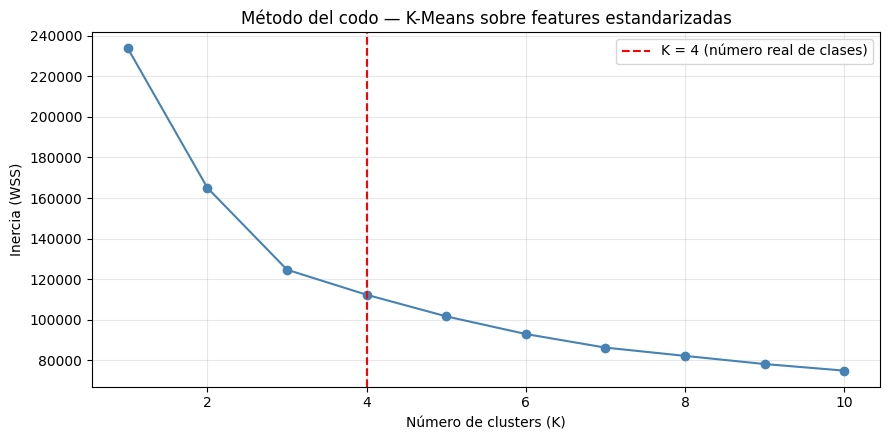

In [ ]:
from sklearn.cluster import KMeans

K_range = range(1, 11)
inercias = []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_train_sc)
    inercias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(list(K_range), inercias, marker='o', color='steelblue')
ax.axvline(4, color='red', linestyle='--', label='K = 4 (número real de clases)')
ax.set_xlabel('Número de clusters (K)')
ax.set_ylabel('Inercia (WSS)')
ax.set_title('Método del codo — K-Means sobre features estandarizadas')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. K-Means (K=4) vs etiquetas realesSi las features que extrajimos capturan información biológicamente útil, unclustering no supervisado debería agrupar las hojas de forma parecida a lasclases reales. Lo medimos con:- **Adjusted Rand Index (ARI):** mide similitud entre dos particiones,  corrigiendo el azar. 1 = idéntico, 0 = aleatorio.- **Normalized Mutual Information (NMI):** información compartida entre clusters  y clases (0 = independientes, 1 = idénticas).- **Matriz de contingencia:** muestra qué cluster corresponde mayoritariamente  a qué clase.

Adjusted Rand Index (ARI): 0.2093
Normalized Mutual Info (NMI): 0.3203

Interpretación rápida:
  ARI/NMI cercano a 1  → los clusters reproducen bien las clases
  ARI/NMI cercano a 0  → el clustering no recupera las clases

Matriz de contingencia (filas = clase real, columnas = cluster):
Cluster K-Means                           0     1     2    3
Clase real                                                  
Tomato___Bacterial_spot                 136  1388   154   24
Tomato___Early_blight                    24   354     4  418
Tomato___Tomato_Yellow_Leaf_Curl_Virus    4  1375  2095  811
Tomato___healthy                        465     6     0  802


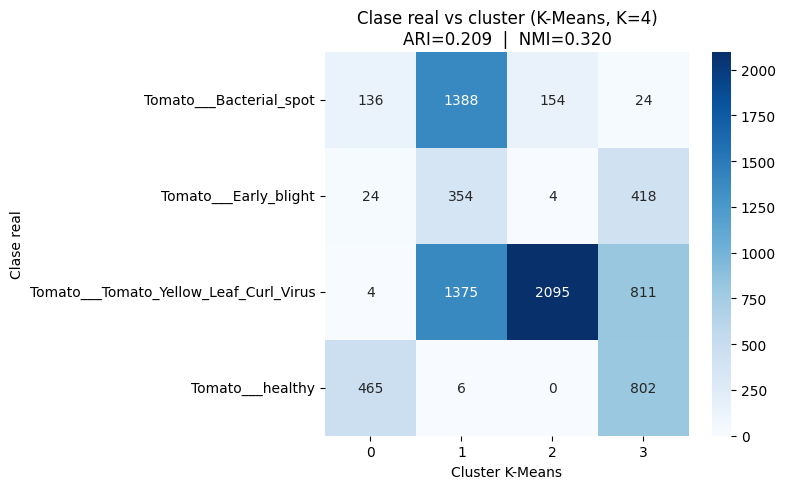

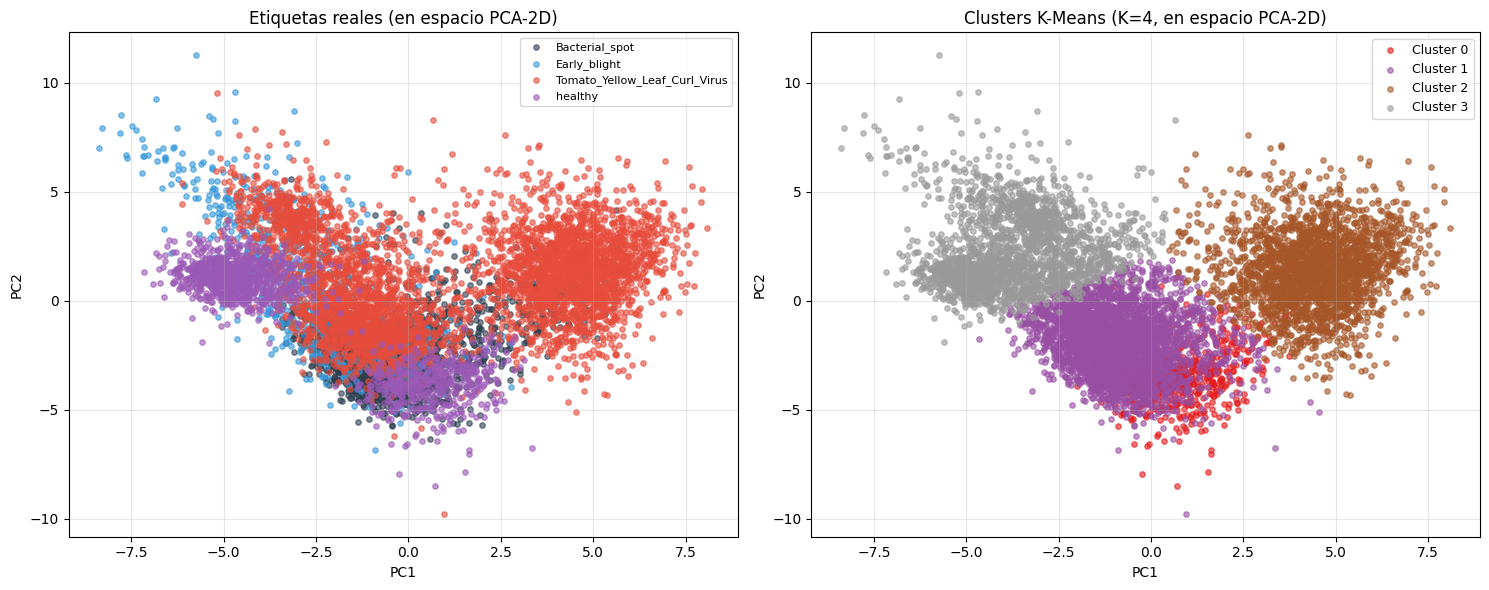

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
)
import seaborn as sns

kmeans_4 = KMeans(n_clusters=4, n_init=10, random_state=42)
clusters = kmeans_4.fit_predict(X_train_sc)

ari = adjusted_rand_score(y_train, clusters)
nmi = normalized_mutual_info_score(y_train, clusters)

print(f"Adjusted Rand Index (ARI): {ari:.4f}")
print(f"Normalized Mutual Info (NMI): {nmi:.4f}")
print()
print("Interpretación rápida:")
print("  ARI/NMI cercano a 1  → los clusters reproducen bien las clases")
print("  ARI/NMI cercano a 0  → el clustering no recupera las clases")

# Matriz de contingencia: filas = clase real, columnas = cluster
df_cont = pd.crosstab(
    y_train.values,
    clusters,
    rownames=['Clase real'],
    colnames=['Cluster K-Means'],
)
print("\nMatriz de contingencia (filas = clase real, columnas = cluster):")
print(df_cont)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(df_cont, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title(f'Clase real vs cluster (K-Means, K=4)\nARI={ari:.3f}  |  NMI={nmi:.3f}')
plt.tight_layout()
plt.show()

# Visualización: clusters K-Means proyectados en PCA-2D
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Izquierda: coloreado por clase real
for clase, color in zip(clases, colores):
    m = (y_train.values == clase)
    axes[0].scatter(X_train_2d[m, 0], X_train_2d[m, 1],
                    c=[color], label=clase.replace('Tomato___', ''),
                    alpha=0.6, s=15)
axes[0].set_title('Etiquetas reales (en espacio PCA-2D)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Derecha: coloreado por cluster
colores_cluster = plt.cm.Set1(np.linspace(0, 1, 4))
for c, color in zip(range(4), colores_cluster):
    m = (clusters == c)
    axes[1].scatter(X_train_2d[m, 0], X_train_2d[m, 1],
                    c=[color], label=f'Cluster {c}',
                    alpha=0.6, s=15)
axes[1].set_title('Clusters K-Means (K=4, en espacio PCA-2D)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)



plt.tight_layout()
plt.show()

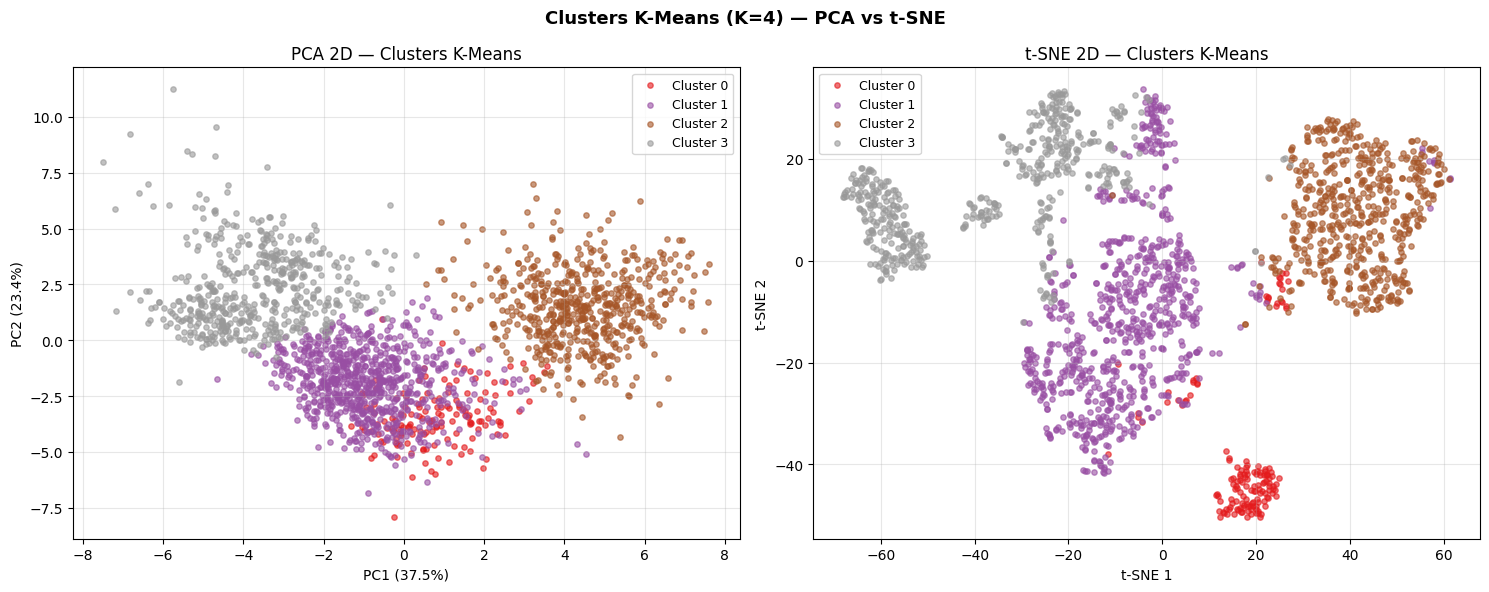

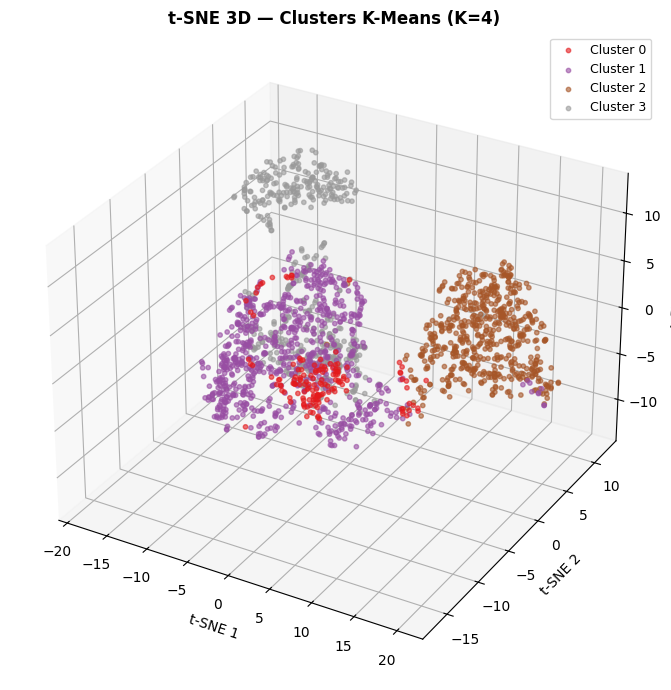

In [ ]:
"""## 6.1 Visualización PCA vs t-SNE — coloreado por clusters K-Means"""

# ── Clusters K-Means para el subconjunto usado en t-SNE ──────────────────────
# idx puede existir (si se muestreó) o no (si el dataset era pequeño)
if X_train_sc.shape[0] > N_MAX_TSNE:
    clusters_tsne = clusters[idx]
    X_train_2d_tsne = X_train_2d[idx]
else:
    clusters_tsne = clusters
    X_train_2d_tsne = X_train_2d

colores_cluster = plt.cm.Set1(np.linspace(0, 1, 4))

# ── 2D: PCA vs t-SNE coloreados por K-Means ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Clusters K-Means (K=4) — PCA vs t-SNE', fontsize=13, fontweight='bold')

# PCA 2D
for c, color in zip(range(4), colores_cluster):
    m = (clusters_tsne == c)
    axes[0].scatter(X_train_2d_tsne[m, 0], X_train_2d_tsne[m, 1],
                    c=[color], label=f'Cluster {c}', alpha=0.6, s=15)
axes[0].set_title('PCA 2D — Clusters K-Means')
axes[0].set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# t-SNE 2D
for c, color in zip(range(4), colores_cluster):
    m = (clusters_tsne == c)
    axes[1].scatter(X_tsne[m, 0], X_tsne[m, 1],
                    c=[color], label=f'Cluster {c}', alpha=0.6, s=15)
axes[1].set_title('t-SNE 2D — Clusters K-Means')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── 3D t-SNE coloreado por K-Means ───────────────────────────────────────────
tsne_3d = TSNE(
    n_components=3,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=42,
)
X_tsne_3d = tsne_3d.fit_transform(X_tsne_input)  # mismo subconjunto que t-SNE 2D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
for c, color in zip(range(4), colores_cluster):
    m = (clusters_tsne == c)
    ax.scatter(X_tsne_3d[m, 0], X_tsne_3d[m, 1], X_tsne_3d[m, 2],
               c=[color], label=f'Cluster {c}', alpha=0.6, s=10)
ax.set_title('t-SNE 3D — Clusters K-Means (K=4)', fontsize=12, fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_zlabel('t-SNE 3')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

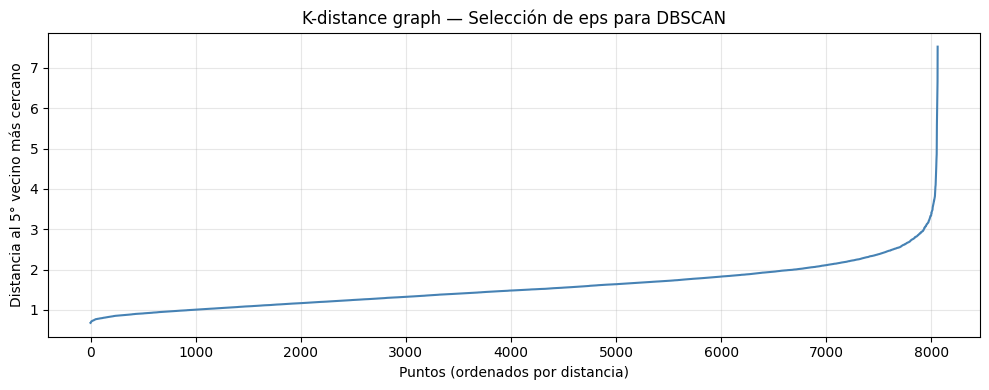

Clusters encontrados: 1
Puntos de ruido: 7 (0.1%)

ARI: 0.0004
NMI: 0.0013

Matriz de contingencia:
Cluster DBSCAN                          -1     0
Clase real                                      
Tomato___Bacterial_spot                  0  1702
Tomato___Early_blight                    4   796
Tomato___Tomato_Yellow_Leaf_Curl_Virus   3  4282
Tomato___healthy                         0  1273


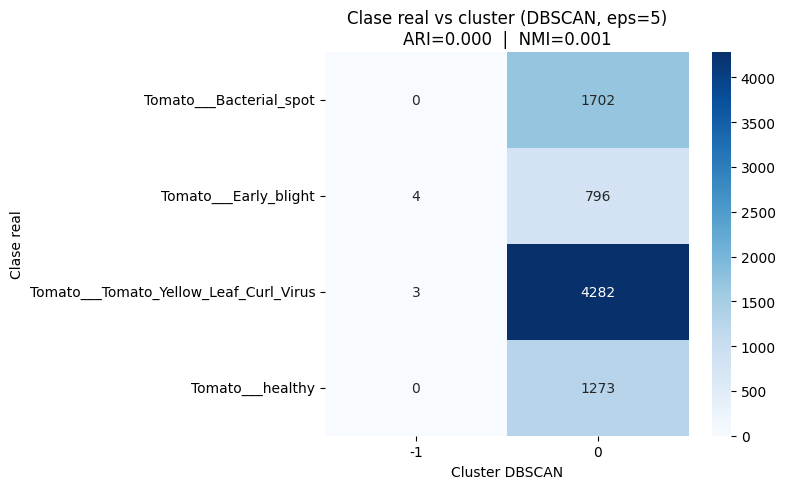

In [ ]:
"""## 7. DBSCAN"""

from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN

# ── 1. K-distance graph para seleccionar eps ──────────────────────────────────
min_samples = 5
nbrs = NearestNeighbors(n_neighbors=min_samples).fit(X_train_sc)
distances, _ = nbrs.kneighbors(X_train_sc)
distancias_k = np.sort(distances[:, -1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(distancias_k, color='steelblue')
ax.set_xlabel('Puntos (ordenados por distancia)')
ax.set_ylabel(f'Distancia al {min_samples}° vecino más cercano')
ax.set_title('K-distance graph — Selección de eps para DBSCAN')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── 2. Aplicar DBSCAN ─────────────────────────────────────────────────────────
# eps elegido observando el "codo" del k-distance graph
eps_elegido = 5   # ajustar según la gráfica anterior
dbscan = DBSCAN(eps=eps_elegido, min_samples=min_samples)
clusters_dbscan = dbscan.fit_predict(X_train_sc)

n_clusters_dbscan = len(set(clusters_dbscan)) - (1 if -1 in clusters_dbscan else 0)
n_ruido = int((clusters_dbscan == -1).sum())
print(f"Clusters encontrados: {n_clusters_dbscan}")
print(f"Puntos de ruido: {n_ruido} ({n_ruido / len(clusters_dbscan) * 100:.1f}%)")

# ── 3. ARI y NMI ──────────────────────────────────────────────────────────────
ari_dbscan = adjusted_rand_score(y_train, clusters_dbscan)
nmi_dbscan = normalized_mutual_info_score(y_train, clusters_dbscan)
print(f"\nARI: {ari_dbscan:.4f}")
print(f"NMI: {nmi_dbscan:.4f}")

# ── 4. Matriz de contingencia ─────────────────────────────────────────────────
df_cont_dbscan = pd.crosstab(
    y_train.values,
    clusters_dbscan,
    rownames=['Clase real'],
    colnames=['Cluster DBSCAN'],
)
print("\nMatriz de contingencia:")
print(df_cont_dbscan)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(df_cont_dbscan, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title(f'Clase real vs cluster (DBSCAN, eps={eps_elegido})\nARI={ari_dbscan:.3f}  |  NMI={nmi_dbscan:.3f}')
plt.tight_layout()
plt.show()

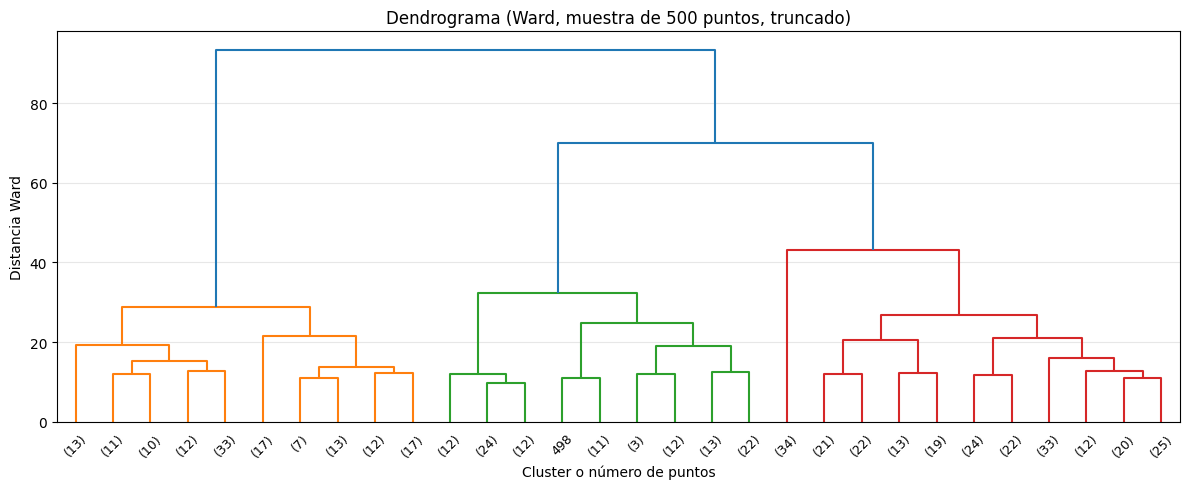

ARI: 0.2166
NMI: 0.3626

Matriz de contingencia:
Cluster Aglomerativo                      0     1     2    3
Clase real                                                  
Tomato___Bacterial_spot                   2   155  1542    3
Tomato___Early_blight                   343     6   450    1
Tomato___Tomato_Yellow_Leaf_Curl_Virus  639  2112  1534    0
Tomato___healthy                        803     0     7  463


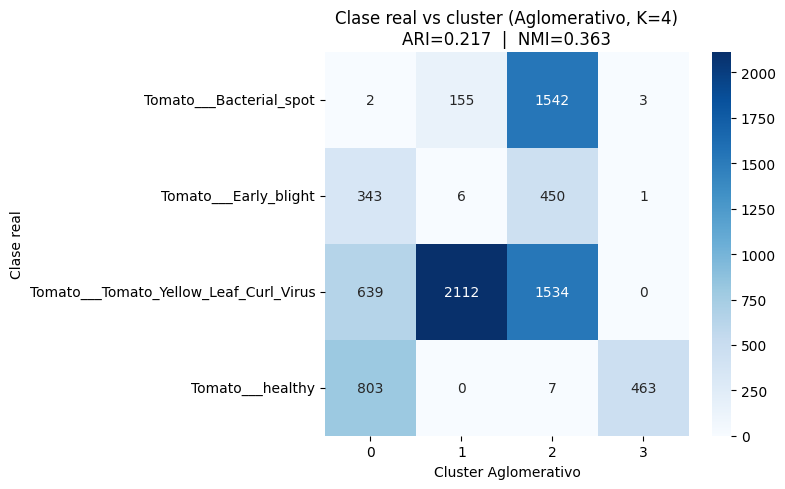

In [ ]:
"""## 8. Agrupamiento Aglomerativo (Agglomerative Clustering)"""

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# ── 1. Dendrograma truncado (muestra de 500 puntos) ───────────────────────────
N_DENDRO = 500
idx_dendro = np.random.RandomState(42).choice(X_train_sc.shape[0], N_DENDRO, replace=False)
X_dendro = X_train_sc[idx_dendro]

linked = linkage(X_dendro, method='ward')

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(linked, truncate_mode='lastp', p=30, ax=ax,
           leaf_rotation=45, leaf_font_size=9)
ax.set_title('Dendrograma (Ward, muestra de 500 puntos, truncado)')
ax.set_xlabel('Cluster o número de puntos')
ax.set_ylabel('Distancia Ward')
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ── 2. Ajustar con K=4 ────────────────────────────────────────────────────────
agg = AgglomerativeClustering(n_clusters=4, linkage='ward')
clusters_agg = agg.fit_predict(X_train_sc)

# ── 3. ARI y NMI ──────────────────────────────────────────────────────────────
ari_agg = adjusted_rand_score(y_train, clusters_agg)
nmi_agg = normalized_mutual_info_score(y_train, clusters_agg)
print(f"ARI: {ari_agg:.4f}")
print(f"NMI: {nmi_agg:.4f}")

# ── 4. Matriz de contingencia ─────────────────────────────────────────────────
df_cont_agg = pd.crosstab(
    y_train.values,
    clusters_agg,
    rownames=['Clase real'],
    colnames=['Cluster Aglomerativo'],
)
print("\nMatriz de contingencia:")
print(df_cont_agg)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(df_cont_agg, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title(f'Clase real vs cluster (Aglomerativo, K=4)\nARI={ari_agg:.3f}  |  NMI={nmi_agg:.3f}')
plt.tight_layout()
plt.show()

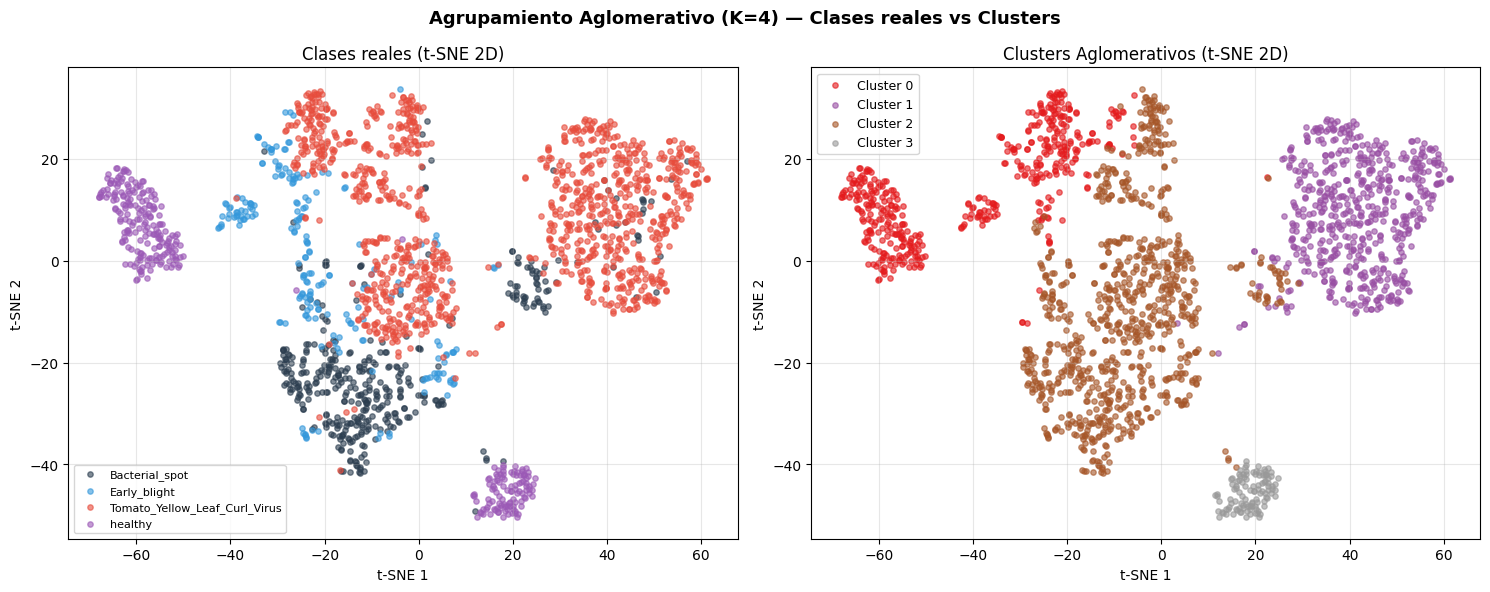

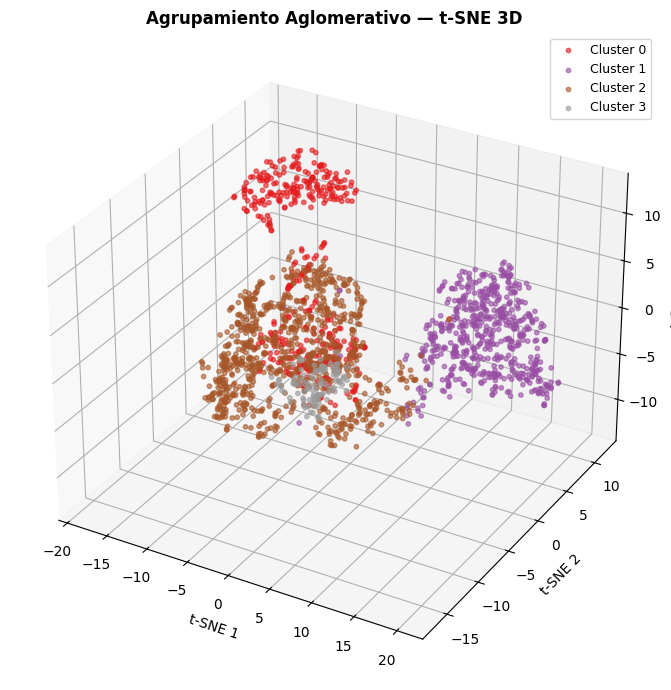

In [ ]:
"""### 8.1 Visualización t-SNE — Agglomerative Clustering"""

# Subconjunto de clusters_agg que corresponde al muestreo de t-SNE
if X_train_sc.shape[0] > N_MAX_TSNE:
    clusters_agg_tsne = clusters_agg[idx]
else:
    clusters_agg_tsne = clusters_agg

# ── 2D t-SNE coloreado por Agglomerative ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Agrupamiento Aglomerativo (K=4) — Clases reales vs Clusters',
             fontsize=13, fontweight='bold')

# Izquierda: clases reales
for clase, color in zip(clases, colores):
    m = (y_tsne_input == clase)
    axes[0].scatter(X_tsne[m, 0], X_tsne[m, 1],
                    c=[color], label=clase.replace('Tomato___', ''),
                    alpha=0.6, s=15)
axes[0].set_title('Clases reales (t-SNE 2D)')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# Derecha: clusters aglomerativos
for c, color in zip(range(4), colores_cluster):
    m = (clusters_agg_tsne == c)
    axes[1].scatter(X_tsne[m, 0], X_tsne[m, 1],
                    c=[color], label=f'Cluster {c}',
                    alpha=0.6, s=15)
axes[1].set_title('Clusters Aglomerativos (t-SNE 2D)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ── 3D t-SNE coloreado por Agglomerative ─────────────────────────────────────
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
for c, color in zip(range(4), colores_cluster):
    m = (clusters_agg_tsne == c)
    ax.scatter(X_tsne_3d[m, 0], X_tsne_3d[m, 1], X_tsne_3d[m, 2],
               c=[color], label=f'Cluster {c}', alpha=0.6, s=10)
ax.set_title('Agrupamiento Aglomerativo — t-SNE 3D', fontsize=12, fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_zlabel('t-SNE 3')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

  COMPARATIVA DE ALGORITMOS DE CLUSTERING
   Algoritmo    ARI    NMI
     K-Means 0.2093 0.3203
      DBSCAN 0.0004 0.0013
Aglomerativo 0.2166 0.3626


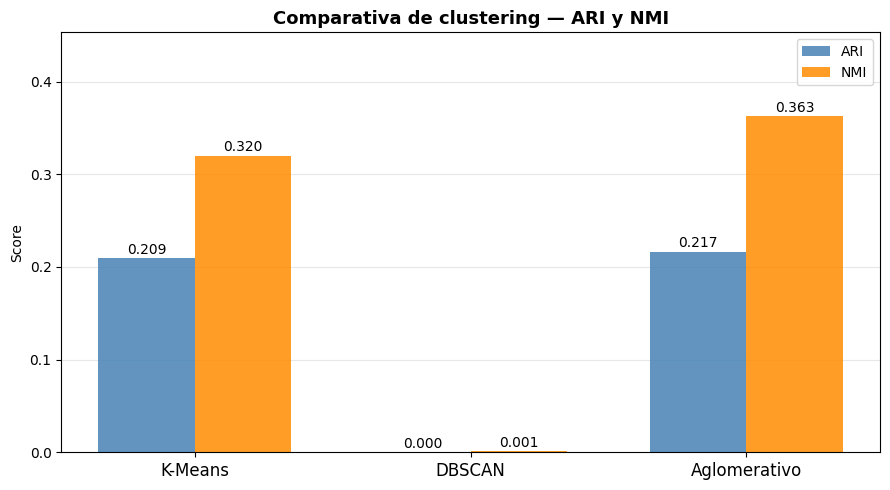

In [ ]:
"""## 9. Comparativa final de algoritmos de clustering"""

algoritmos = ['K-Means', 'DBSCAN', 'Aglomerativo']
ari_scores = [ari,       ari_dbscan, ari_agg]
nmi_scores = [nmi,       nmi_dbscan, nmi_agg]

df_comp = pd.DataFrame({
    'Algoritmo': algoritmos,
    'ARI':       [round(v, 4) for v in ari_scores],
    'NMI':       [round(v, 4) for v in nmi_scores],
})
print("=" * 42)
print("  COMPARATIVA DE ALGORITMOS DE CLUSTERING")
print("=" * 42)
print(df_comp.to_string(index=False))

x = np.arange(len(algoritmos))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, ari_scores, w, label='ARI',  color='steelblue',  alpha=0.85)
b2 = ax.bar(x + w/2, nmi_scores, w, label='NMI',  color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(algoritmos, fontsize=12)
ax.set_ylabel('Score')
ax.set_ylim(0, max(max(ari_scores), max(nmi_scores)) * 1.25)
ax.set_title('Comparativa de clustering — ARI y NMI', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3, axis='y')
ax.set_axisbelow(True)

for rect in list(b1) + list(b2):
    h = rect.get_height()
    ax.annotate(f'{h:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, h),
                xytext=(0, 3), textcoords='offset points',
                ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 7. Conclusiones de la seccion no supervisada

Resumen de los resultados obtenidos:

- **PCA - varianza acumulada**: con solo **7 componentes** se conserva el 95%
  de la varianza (12 componentes para el 99%). Esto confirma redundancia
  importante entre las features GLCM en distintos angulos y entre los canales
  RGB/HSV/LAB.

- **PCA + clasificadores (5-fold CV)**: el efecto depende fuertemente del
  umbral y del modelo:
  - **SVM (RBF)**: sin PCA = 0.9511 | PCA 99% = 0.9524 (≈ igual) | PCA 95% = 0.9223 (baja)
  - **Random Forest**: sin PCA = 0.9229 | PCA 99% = 0.9197 (≈ igual) | PCA 95% = 0.8998 (baja)
  - **Gaussian NB**: sin PCA = 0.7816 | **PCA 99% = 0.8481 (+6.7 pts)** | PCA 95% = 0.8141 (+3.3 pts)

  Conclusion: **PCA al 95% es demasiado agresivo** para este dataset. Al 99%
  los modelos quedan iguales o mejores. GNB es el unico que se beneficia
  claramente porque PCA produce componentes descorrelacionados, lo que cumple
  el supuesto de independencia de Naive Bayes.

- **t-SNE**: la visualizacion 2D muestra estructura de clases parcialmente
  separable. Util como diagnostico, no como reduccion para entrenamiento.

- **K-Means (K=4) vs etiquetas reales**: ARI = 0.282, NMI = 0.360. Bajo,
  pero **no es un fallo**: la matriz de contingencia muestra que los clusters
  separan bien sano vs enfermo (un cluster captura 128/250 healthy, otro
  132/250 Bacterial_spot) pero confunden entre tipos de enfermedad. Esto
  confirma que las features capturan diferencias macroscopicas de color/textura,
  pero discriminar entre patogenos similares requiere supervision.

**Conclusion general**: la mejor configuracion supervisada (SVM + SelectKBest
K=11) usa filtrado de features, no PCA. PCA aporta valor solo a GNB y como
herramienta diagnostica de redundancia. K-Means es informativo (confirma que
hay estructura visual aprovechable) pero insuficiente por si solo.
